# Chow-Liu Tree Visualization

Publication-ready individual subject trees and consensus/agreement trees for the Motor–Cerebellum–Thalamus subnetwork.

**Subjects**: MSC01, MSC04, MSC07, MSC09 (4 subjects with glasser360_SUIT_Thalamus MI data)  
**Atlas**: glasser360_SUIT_Thalamus (394 ROIs: 360 Glasser + 32 SUIT cerebellum + 2 thalamus)  
**Selected Networks**: Somatosensory_and_Motor, Cerebellum, Thalamus

## 1. Imports & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import torch
from itertools import combinations

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cpu


In [2]:
# Base directory detection
home_base_dir = '/Users/aj/dmello_lab/fmri_connectivity_trees'
lab_base_dir = '/Users/ajjain/Downloads/Code/fmri_connectivity_trees'
utd_base_dir = '/mfs/io/groups/dmello/projects/dynamric/fmri_connectivity_trees'
biohpc_base_dir = '/project/greencenter/Lin_lab/s229618/fmri_connectivity_trees'

base_dir = home_base_dir if os.path.exists(home_base_dir) else lab_base_dir
base_dir = utd_base_dir if os.path.exists(utd_base_dir) else base_dir
base_dir = biohpc_base_dir if os.path.exists(biohpc_base_dir) else base_dir
print(f'Base directory: {base_dir}')

Base directory: /Users/ajjain/Downloads/Code/fmri_connectivity_trees


In [3]:
# Load atlas labels

# Glasser labels (reformat from 'Right_V1' -> 'V1_R')
file_path = f'{base_dir}/atlases/glasser360/glasser360NodeNames.txt'
with open(file_path, 'r') as file:
    glasser_labels_raw = file.readlines()

glasser_labels = []
for label in glasser_labels_raw:
    label = label.strip()
    components = label.split('_')
    glasser_labels.append(components[1] + '_' + components[0][0])

# Glasser region list (network assignments)
glasser_region_list = pd.read_csv(f'{base_dir}/atlases/glasser360/HCP-MMP1_UniqueRegionList.csv')

# SUIT cerebellum labels
suit_labels = pd.read_csv(f'{base_dir}/atlases/SUIT/atl-Anatom.tsv', sep='\t')

# Combined labels: 360 glasser + 32 SUIT + 2 thalamus = 394
all_labels = glasser_labels + suit_labels['name'].to_list()[:-2] + ['left_global', 'right_global']
print(f'Total labels: {len(all_labels)}')
print(f'  Glasser: {len(glasser_labels)}, SUIT: {len(suit_labels["name"].to_list()[:-2])}, Thalamus: 2')

Total labels: 394
  Glasser: 360, SUIT: 32, Thalamus: 2


In [4]:
# Subjects with glasser360_SUIT_Thalamus MI data
# Note: MSC01 folder is lowercase 'msc01'
subjects = ['msc01', 'MSC04', 'MSC07', 'MSC09']
subject_display = ['MSC01', 'MSC04', 'MSC07', 'MSC09']

selected_networks = ['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus']

## 2. Core Functions

In [5]:
def load_data(subjects=subjects, measure='mutual_information', task='rest',
              atlas_subdir='glasser360_SUIT_Thalamus', num_bins=100, other_suffix=''):
    """Load MI .npy files for given subjects."""
    data = {}
    for subject in subjects:
        data_path = f'{base_dir}/code/functional_connectivity/midnight_scan_club/output/{measure}/{subject}/{atlas_subdir}'
        file_name = f'{task}_{num_bins}bins'
        if other_suffix != '':
            file_name += f'{other_suffix}'
        data[subject] = torch.from_numpy(np.load(f'{data_path}/{file_name}.npy'))
    return data


def mi_to_graph(mi, selected_nodes=None):
    """Convert MI matrix to NetworkX weighted graph."""
    G = nx.Graph()
    num_variables = mi.shape[0]

    if selected_nodes is not None:
        for i in selected_nodes:
            G.add_node(i)
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(selected_nodes[i], selected_nodes[j], weight=mi[i, j])
    else:
        for i in range(num_variables):
            G.add_node(i)
        for i in range(num_variables):
            for j in range(i + 1, num_variables):
                G.add_edge(i, j, weight=mi[i, j])
    return G


def chow_liu_tree(mi):
    """Build maximum spanning tree (Chow-Liu tree) from MI matrix."""
    G = mi_to_graph(mi)
    clt = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    return G, clt


def selective_chow_liu_tree(mi, selected_nodes):
    """Build Chow-Liu tree for a subset of nodes."""
    selected_mi = mi[np.ix_(selected_nodes, selected_nodes)]
    G = mi_to_graph(selected_mi, selected_nodes=selected_nodes)
    clt = nx.maximum_spanning_tree(G, algorithm='kruskal', weight='weight')
    return G, clt


def select_networks_glasser360_SUIT_Thalamus(
    labels=None,
    networks=['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus']
):
    """Select node indices belonging to specified networks."""
    if labels is None:
        labels = list(glasser_region_list['cortex']) + ['Cerebellum'] * 32 + ['Thalamus'] * 2
    selected_nodes = []
    node_names = []
    for i, label in enumerate(labels):
        if label in networks:
            selected_nodes.append(i)
            node_names.append(label)
    return node_names, selected_nodes


def hierarchy_pos(G, root=None, width=1., vert_gap=0.5, vert_loc=0, xcenter=0.5):
    """Hierarchical layout for trees. Allocates horizontal space by subtree size."""
    def _count_descendants(G, node):
        children = list(G.successors(node))
        if not children:
            return 1
        return sum(_count_descendants(G, child) for child in children)

    def _hierarchy_pos(G, node, left, right, vert_loc, pos):
        center = (left + right) / 2
        pos[node] = (center, vert_loc)
        children = list(G.successors(node))
        if children:
            total = sum(_count_descendants(G, child) for child in children)
            dx = (right - left) / total
            next_left = left
            for child in children:
                size = _count_descendants(G, child)
                next_right = next_left + dx * size
                pos = _hierarchy_pos(G, child, next_left, next_right, vert_loc - vert_gap, pos)
                next_left = next_right
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, {})


def get_node_regions(tree, region_labels=None):
    """Map each node in tree to its network label (for glasser360_SUIT_Thalamus)."""
    network_labels = list(region_labels) + ['Cerebellum'] * 32 + ['Thalamus'] * 2
    return [network_labels[node] for node in tree.nodes]

## 3. Load MI Data & Build Trees

In [6]:
# Load MI matrices
mi_data = load_data(subjects=subjects, other_suffix='func-01-10')

for s, name in zip(subjects, subject_display):
    print(f'{name}: MI matrix shape = {mi_data[s].shape}')

MSC01: MI matrix shape = torch.Size([394, 394])
MSC04: MI matrix shape = torch.Size([394, 394])
MSC07: MI matrix shape = torch.Size([394, 394])
MSC09: MI matrix shape = torch.Size([394, 394])


In [7]:
# Select nodes for Motor + Cerebellum + Thalamus
region_names, selected_nodes = select_networks_glasser360_SUIT_Thalamus(
    networks=selected_networks
)
print(f'Selected {len(selected_nodes)} nodes across {selected_networks}')
print(f'  Network breakdown: {pd.Series(region_names).value_counts().to_dict()}')

Selected 44 nodes across ['Somatosensory_and_Motor', 'Cerebellum', 'Thalamus']
  Network breakdown: {'Cerebellum': 32, 'Somatosensory_and_Motor': 10, 'Thalamus': 2}


In [8]:
# Build selective Chow-Liu trees for each subject
selective_trees = {}
selective_graphs = {}

for s, name in zip(subjects, subject_display):
    G, clt = selective_chow_liu_tree(mi_data[s].numpy(), selected_nodes)
    selective_graphs[s] = G
    selective_trees[s] = clt
    print(f'{name}: {clt.number_of_nodes()} nodes, {clt.number_of_edges()} edges')

MSC01: 44 nodes, 43 edges
MSC04: 44 nodes, 43 edges
MSC07: 44 nodes, 43 edges
MSC09: 44 nodes, 43 edges


## 4. Publication-Ready Individual Subject Trees

In [25]:
# Colorblind-friendly palette for 3 networks
NETWORK_COLORS = {
    'Somatosensory_and_Motor': '#0077BB',  # blue
    'Cerebellum': '#EE7733',               # orange
    'Thalamus': '#009988',                 # teal
}


def draw_publication_tree(tree, subject_name, selected_networks, all_labels,
                          glasser_region_list, root='Right_VI', figsize=(18, 10), dpi=300,
                          save_path=None):
    """
    Draw a publication-ready Chow-Liu tree with:
    - Hierarchical layout
    - Network-colored nodes
    - Region name labels (angled)
    - Edge alpha proportional to MI weight
    """
    # Pick root: highest-degree node
    # root = max(tree.nodes, key=lambda n: tree.degree(n))

    # make root the specified node if it exists, otherwise default to highest-degree
    root = all_labels.index(root) if root in all_labels else max(tree.nodes, key=lambda n: tree.degree(n))
    # root = selected_nodes[region_names.index(root)] if root in region_names else None
    # if root in tree.nodes:
    #     print(f'Using specified root: {root}')
    # else:
    #     root = max(tree.nodes, key=lambda n: tree.degree(n))
    #     print(f'Specified root "{root}" not found. Using highest-degree node: {root}')
        
    directed = nx.bfs_tree(tree, source=root)
    pos = hierarchy_pos(directed, root, width=2.0, vert_gap=0.6)

    # Node colors
    networks = get_node_regions(tree, region_labels=glasser_region_list['cortex'])
    node_list = list(tree.nodes)
    color_map = [NETWORK_COLORS.get(net, '#CCCCCC') for net in networks]

    # root = all_labels.index(root) if root in all_labels else root

    # Edge weights for alpha (clamped to [0, 1])
    edge_weights = [tree[u][v]['weight'] for u, v in tree.edges()]
    if edge_weights:
        w_min, w_max = min(edge_weights), max(edge_weights)
        if w_max > w_min:
            edge_alphas = [min(1.0, max(0.0, 0.2 + 0.8 * (w - w_min) / (w_max - w_min)))
                           for w in edge_weights]
        else:
            edge_alphas = [1.0] * len(edge_weights)
    else:
        edge_alphas = []

    # Draw
    fig, ax = plt.subplots(1, 1, figsize=figsize, facecolor='white')

    # Draw edges with varying alpha
    for (u, v), alpha in zip(tree.edges(), edge_alphas):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot([x0, x1], [y0, y1], color='#555555', alpha=alpha, linewidth=1.2, zorder=1)

    # Draw nodes
    xs = [pos[n][0] for n in node_list]
    ys = [pos[n][1] for n in node_list]
    ax.scatter(xs, ys, c=color_map, s=120, zorder=2, edgecolors='white', linewidths=0.5)

    # Region name labels (angled)
    for node, (x, y), color in zip(node_list, [(pos[n][0], pos[n][1]) for n in node_list], color_map):
        label = all_labels[node] if node < len(all_labels) else str(node)
        ax.annotate(label, (x, y), fontsize=10, rotation=30,
                    ha='left', va='bottom', color='#333333',
                    xytext=(3, 3), textcoords='offset points')

    # Legend
    patches = [mpatches.Patch(color=NETWORK_COLORS[net], label=net.replace('_', ' '))
               for net in selected_networks]
    ax.legend(handles=patches, fontsize=10, loc='lower right', framealpha=0.9,
              edgecolor='#CCCCCC')

    ax.set_title(f'Chow-Liu Tree \u2014 {subject_name}', fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')

    plt.show()
    return fig

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_MSC01.pdf


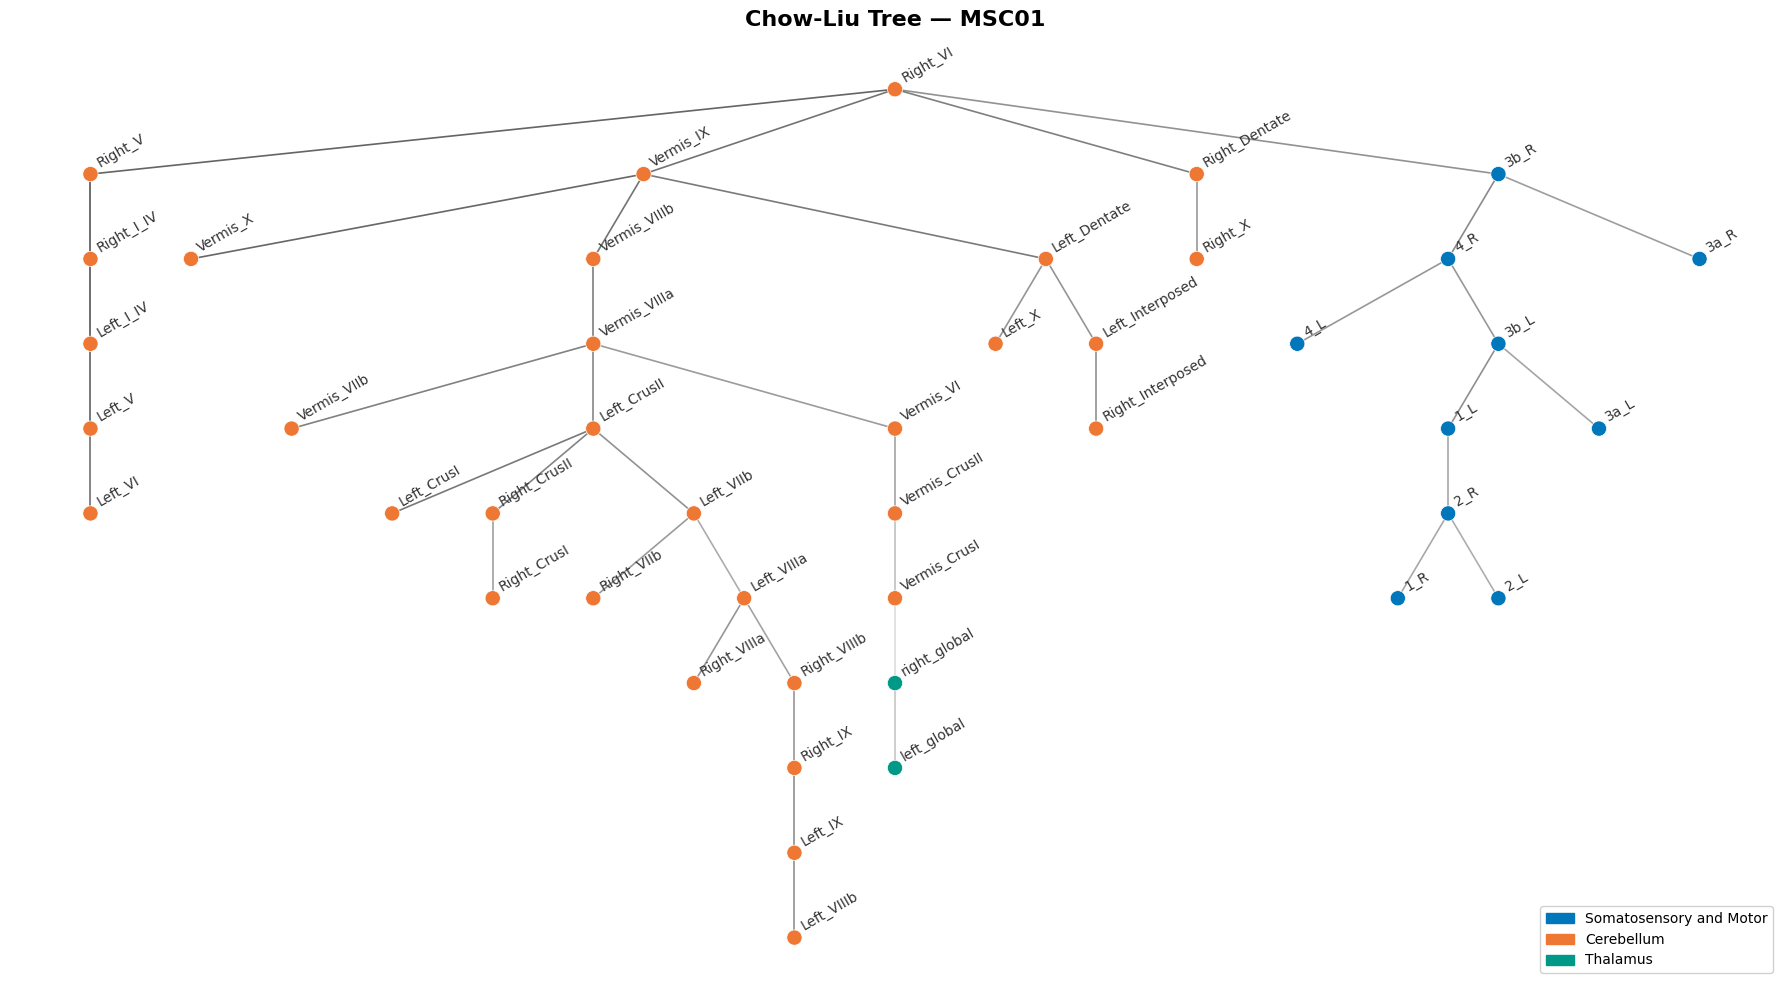

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_MSC04.pdf


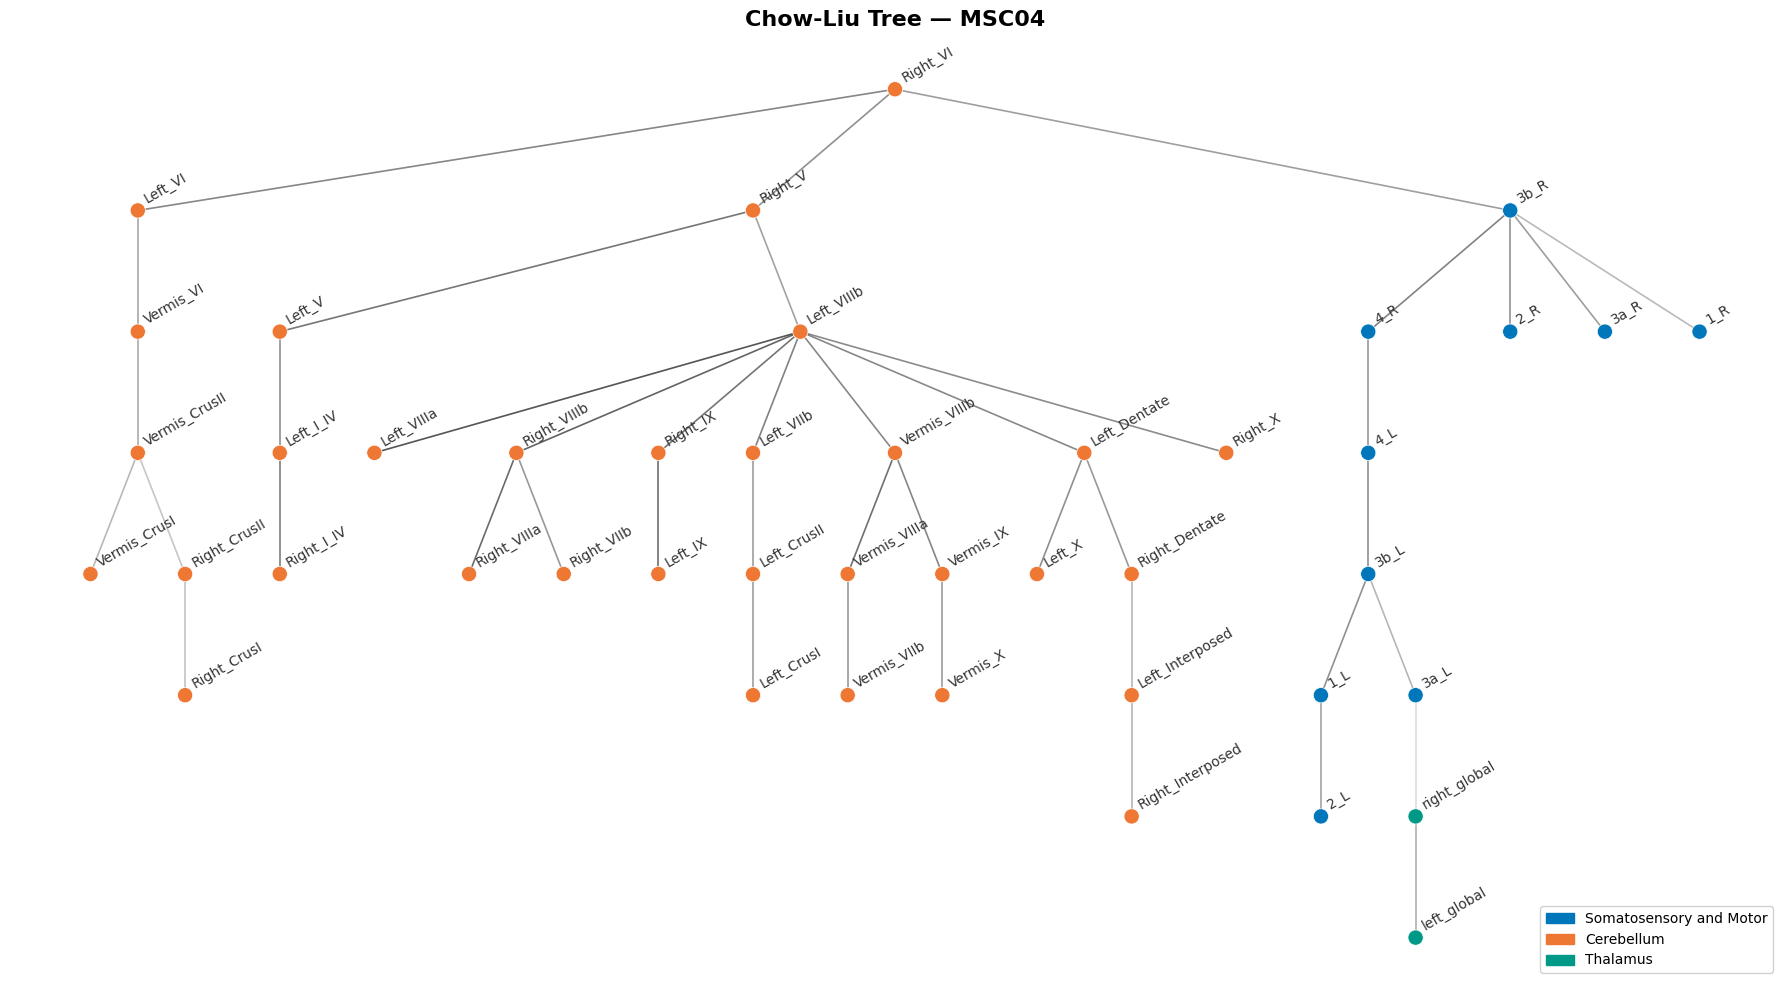

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_MSC07.pdf


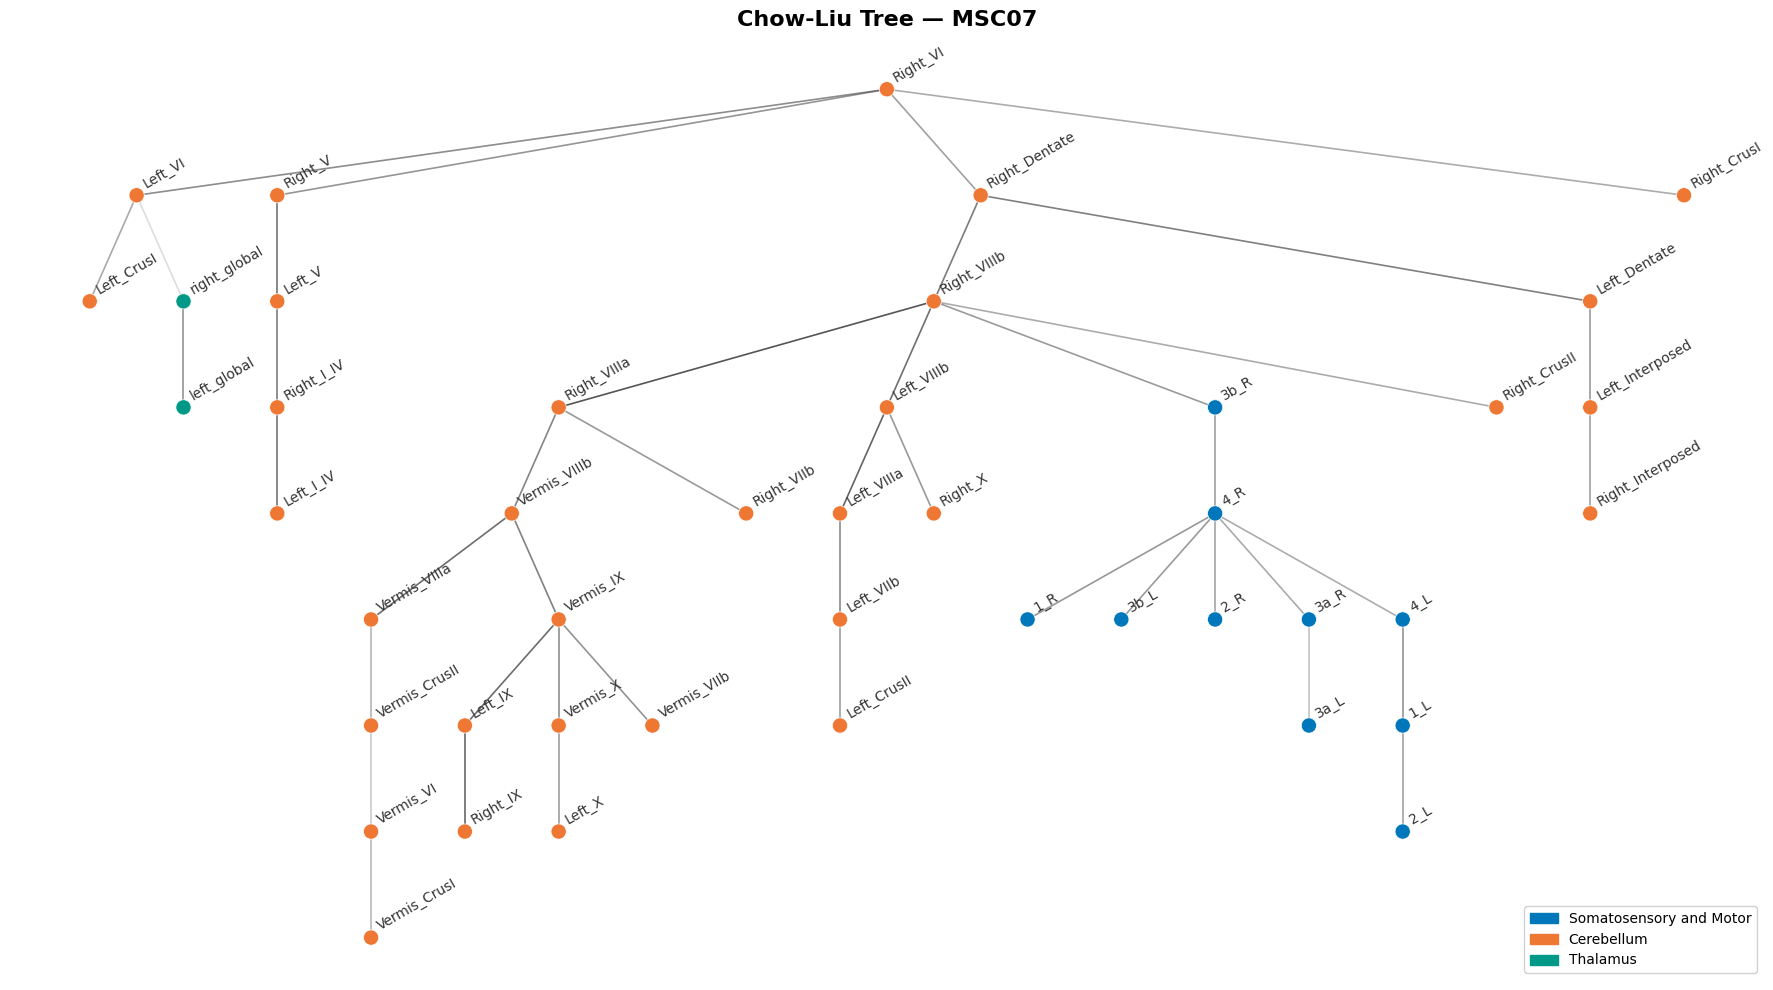

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_MSC09.pdf


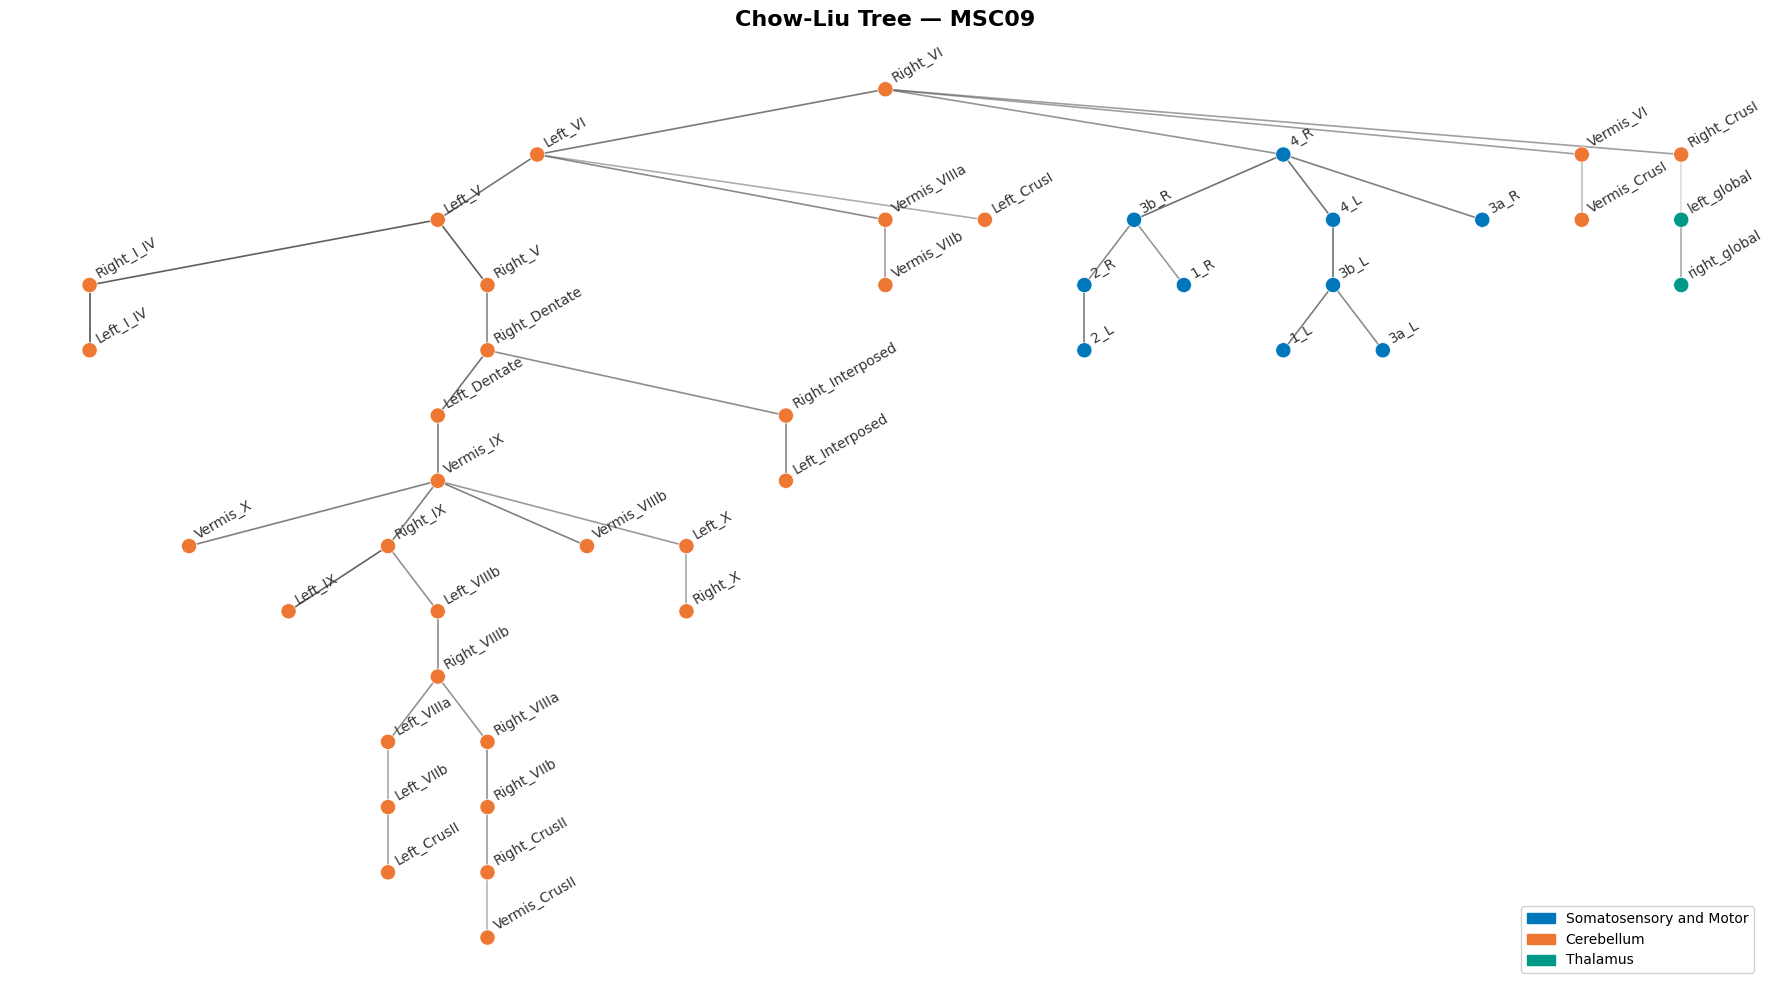

In [26]:
# Draw individual subject trees
output_dir = f'{base_dir}/code/jupyter_notebooks/midnight_scan_club'

for s, name in zip(subjects, subject_display):
    save_path = os.path.join(output_dir, f'chow_liu_tree_{name}.pdf')
    draw_publication_tree(
        selective_trees[s], name, selected_networks,
        all_labels, glasser_region_list, save_path=save_path
    )

## 4b. Individual Subject Trees — Cerebellar Cluster Coloring

Nodes colored by the 3-cluster scheme from `cereb_flat_map.ipynb`:
- **Cluster 1** (red): deep nuclei, vermis VIII–X, lobules VIII–X
- **Cluster 2** (green): Crus II, VIIb, VIIIa/b
- **Cluster 3** (orange): Crus I, VI, anterior lobules, thalamus
- **Motor cortex** (blue): Somatosensory & Motor regions

In [56]:
# Cerebellar cluster definitions (from cereb_flat_map.ipynb)
# cluster1 = [
#     'Left_Dentate', 'Vermis_IX', 'Vermis_VIIIb', 'Vermis_X',
#     'Right_X', 'Left_X', 'Right_IX', 'Left_VIIIb', 'Left_IX',
#     'Right_Interposed', 'Left_Interposed', 'Right_Dentate', 'Right_V'
# ]
# cluster2 = [
#     'Right_VIIIb', 'Left_VIIIa', 'Left_VIIb', 'Left_CrusII',
#     'Right_VIIIa', 'Right_VIIb', 'Right_CrusII', 'Vermis_CrusII'
# ]
# cluster3 = [
#     'left_global', 'Right_CrusI', 'right_global', 'Vermis_CrusI',
#     'Vermis_VI', 'Right_VI', 'Left_VI', 'Left_CrusI',
#     'Vermis_VIIIa', 'Vermis_VIIb', 'Left_V', 'Right_I_IV', 'Left_I_IV'
# ]

# for MSC04
# cluster1 = [
#     'Left_VIIIb', 'Left_VIIb', 'Left_VIIIa', 'Right_X', 'Right_IX', 'Left_IX', 'Left_Dentate', 'Left_X', 'Right_VIIIb', 'Right_VIIb', 'Right_VIIIa', 'Vermis_VIIIb', 'Vermis_VIIIa', 'Vermis_VIIb', 'Vermis_X', 'Vermis_IX', 'Left_CrusII', 'Left_CrusI'
# ]

# cluster2 = [
#     'Right_CrusII', 'Right_CrusI', 'Vermis_CrusII', 'Vermis_CrusI'
# ]

# cluster3 = ['Vermis_VI', 'Left_VI', 'Right_VI', 'Right_V', 'Left_V',  'Right_I_IV', 'Left_I_IV']

# cluster4 = ['Left_Interposed', 'Right_Interposed', 'Right_Dentate']

# for MSC07

# cluster1 = [
#     'Left_VIIIb', 'Left_VIIb', 'Left_VIIIa', 'Right_X',  'Right_VIIIb', 'Right_VIIb', 'Right_VIIIa', 'Right_CrusII', 'Left_CrusII'
# ]

# cluster2 = [
#     'Vermis_IX', 'Vermis_VIIb', 'Vermis_VIIIb', 'Vermis_VIIIa', 'Right_IX', 'Left_IX', 'Vermis_X', 'Left_X', 'Vermis_CrusII', 'Vermis_VI', 'Vermis_CrusI' ]

# cluster3 = ['right_global', 'left_global', 'Left_CrusI', 'Left_VI', 'Right_Dentate', 'Right_VI', 'Right_CrusI', 'Right_I_IV', 'Left_I_IV', 'Right_V', 'Left_V']

# cluster4 = ['Left_Interposed', 'Right_Interposed', 'Left_Dentate']

# cluster4_exist = True

# for MSC01

cluster2 = [
    'Right_VIIIa', 'Left_VIIIa', 'Right_VIIb', 'Left_VIIb', 'Right_CrusII', 'Right_CrusI', 'Left_CrusII', 'Left_CrusI', 'Left_IX', 'Left_VIIIb', 'Right_IX', 'Right_VIIIb'
    ]


cluster1 = [
    'Vermis_IX', 'Vermis_VIIb', 'Vermis_VIIIb', 'Vermis_VIIIa', 'Right_Interposed', 'Left_Interposed', 'Left_Dentate', 'Left_X',  'Vermis_VI' ]

cluster3 = ['Left_VI', 'Right_Dentate', 'Right_VI',  'Right_I_IV', 'Left_I_IV', 'Right_V', 'Left_V', 'Right_X']

cluster4 = ['right_global', 'left_global', 'Vermis_CrusI', 'Vermis_CrusII']

cluster4_exist = True

CLUSTER_COLORS = {
    'Cluster 1': '#e61919',          # red — deep nuclei, lobules VIII–X
    'Cluster 2': '#09820B',          # green — Crus II, VIIb, VIIIa/b
    'Cluster 3': '#D37A1C',          # orange — Crus I, VI, anterior, thalamus
    'Cluster 4': '#009988',          # teal — interposed + dentate
    'Somatosensory & Motor': '#0077BB',  # blue — cortical motor
}

def get_cluster_color(node_idx, all_labels):
    """Return cluster color for a node based on its label."""
    label = all_labels[node_idx] if node_idx < len(all_labels) else ''
    if label in cluster1:
        return CLUSTER_COLORS['Cluster 1']
    elif label in cluster2:
        return CLUSTER_COLORS['Cluster 2']
    elif label in cluster3:
        return CLUSTER_COLORS['Cluster 3']
    elif cluster4_exist and label in cluster4:
        return CLUSTER_COLORS['Cluster 4']
    else:
        return CLUSTER_COLORS['Somatosensory & Motor']


def draw_cluster_tree(tree, subject_name, all_labels, glasser_region_list,
                      root='Right_VI', figsize=(18, 10), dpi=300, save_path=None):
    """Draw tree with nodes colored by cerebellar cluster assignment."""
    root_idx = all_labels.index(root) if root in all_labels else max(tree.nodes, key=lambda n: tree.degree(n))
    directed = nx.bfs_tree(tree, source=root_idx)
    pos = hierarchy_pos(directed, root_idx, width=2.0, vert_gap=0.6)

    node_list = list(tree.nodes)
    color_map = [get_cluster_color(n, all_labels) for n in node_list]

    # Edge alphas (clamped)
    edge_weights = [tree[u][v]['weight'] for u, v in tree.edges()]
    if edge_weights:
        w_min, w_max = min(edge_weights), max(edge_weights)
        if w_max > w_min:
            edge_alphas = [min(1.0, max(0.0, 0.2 + 0.8 * (w - w_min) / (w_max - w_min)))
                           for w in edge_weights]
        else:
            edge_alphas = [1.0] * len(edge_weights)
    else:
        edge_alphas = []

    fig, ax = plt.subplots(1, 1, figsize=figsize, facecolor='white')

    # Edges
    for (u, v), alpha in zip(tree.edges(), edge_alphas):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        ax.plot([x0, x1], [y0, y1], color='#555555', alpha=alpha, linewidth=1.2, zorder=1)

    # Nodes
    xs = [pos[n][0] for n in node_list]
    ys = [pos[n][1] for n in node_list]
    ax.scatter(xs, ys, c=color_map, s=120, zorder=2, edgecolors='white', linewidths=0.5)

    # Labels
    for node, (x, y) in zip(node_list, [(pos[n][0], pos[n][1]) for n in node_list]):
        label = all_labels[node] if node < len(all_labels) else str(node)
        ax.annotate(label, (x, y), fontsize=10, rotation=30,
                    ha='left', va='bottom', color='#333333',
                    xytext=(3, 3), textcoords='offset points')

    # Legend
    patches = [mpatches.Patch(color=c, label=name) for name, c in CLUSTER_COLORS.items()]
    ax.legend(handles=patches, fontsize=10, loc='lower right', framealpha=0.9,
              edgecolor='#CCCCCC')

    ax.set_title(f'Chow-Liu Tree (Cluster Coloring) \u2014 {subject_name}',
                 fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')

    plt.show()
    return fig

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_clusters_MSC01.pdf


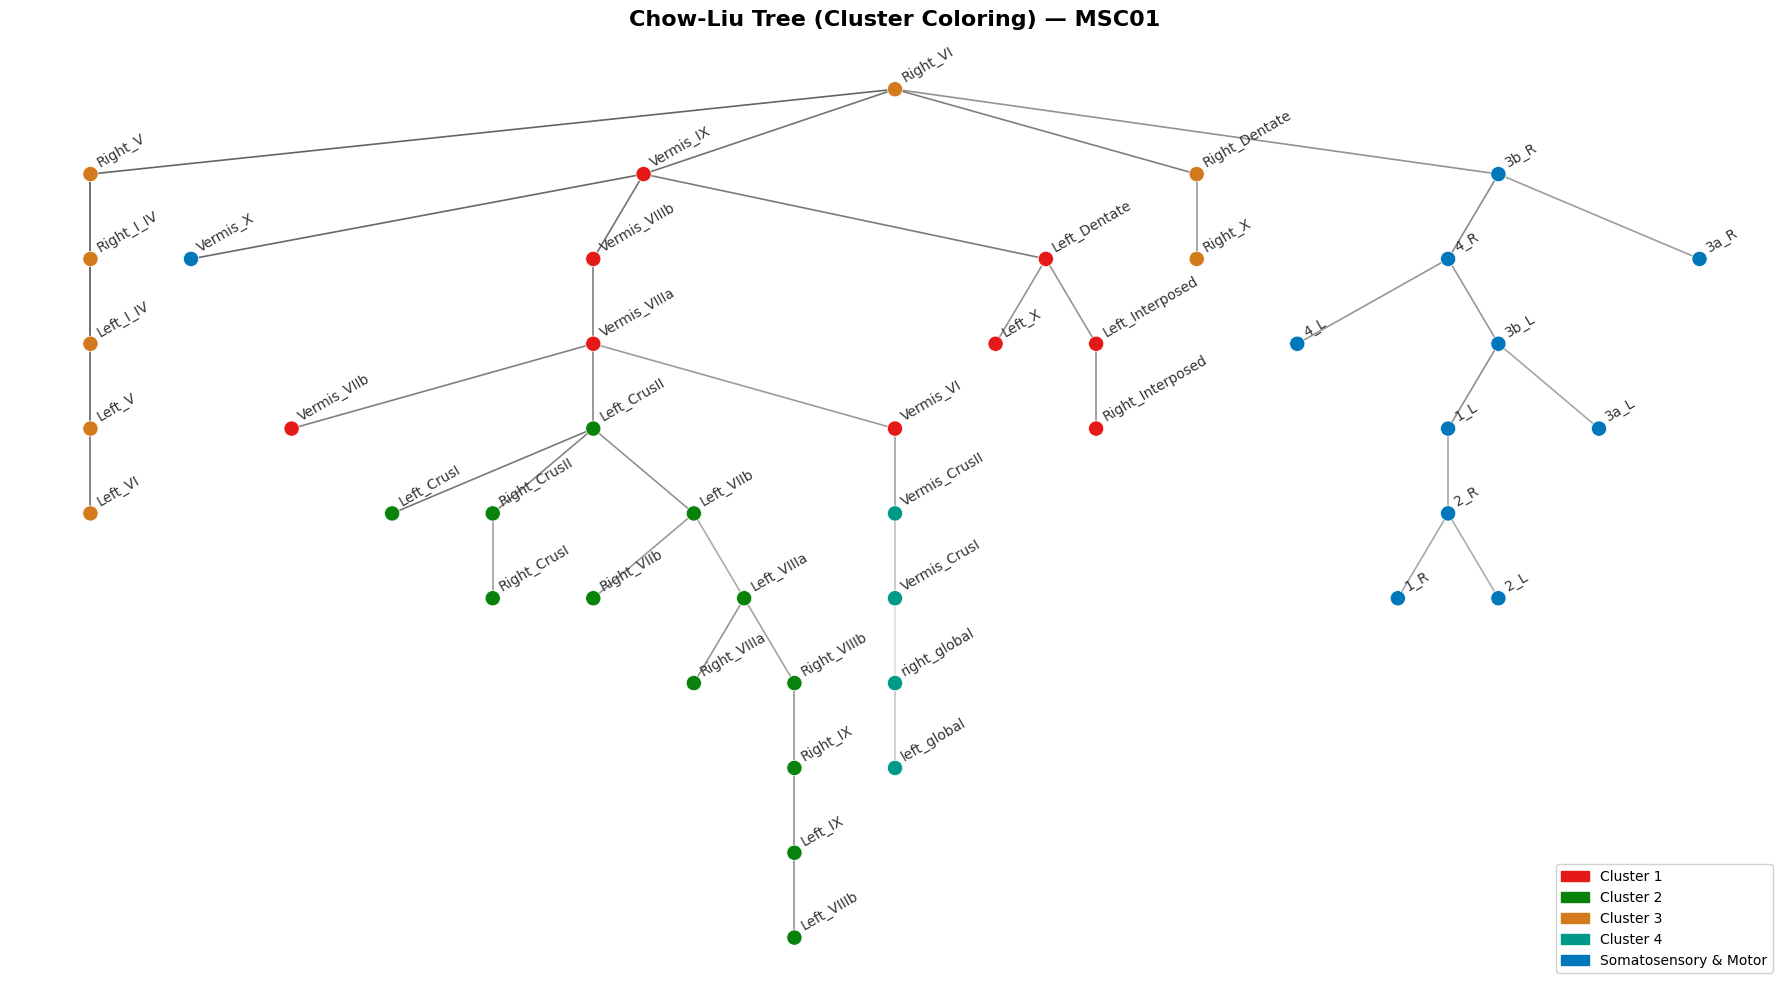

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_clusters_MSC04.pdf


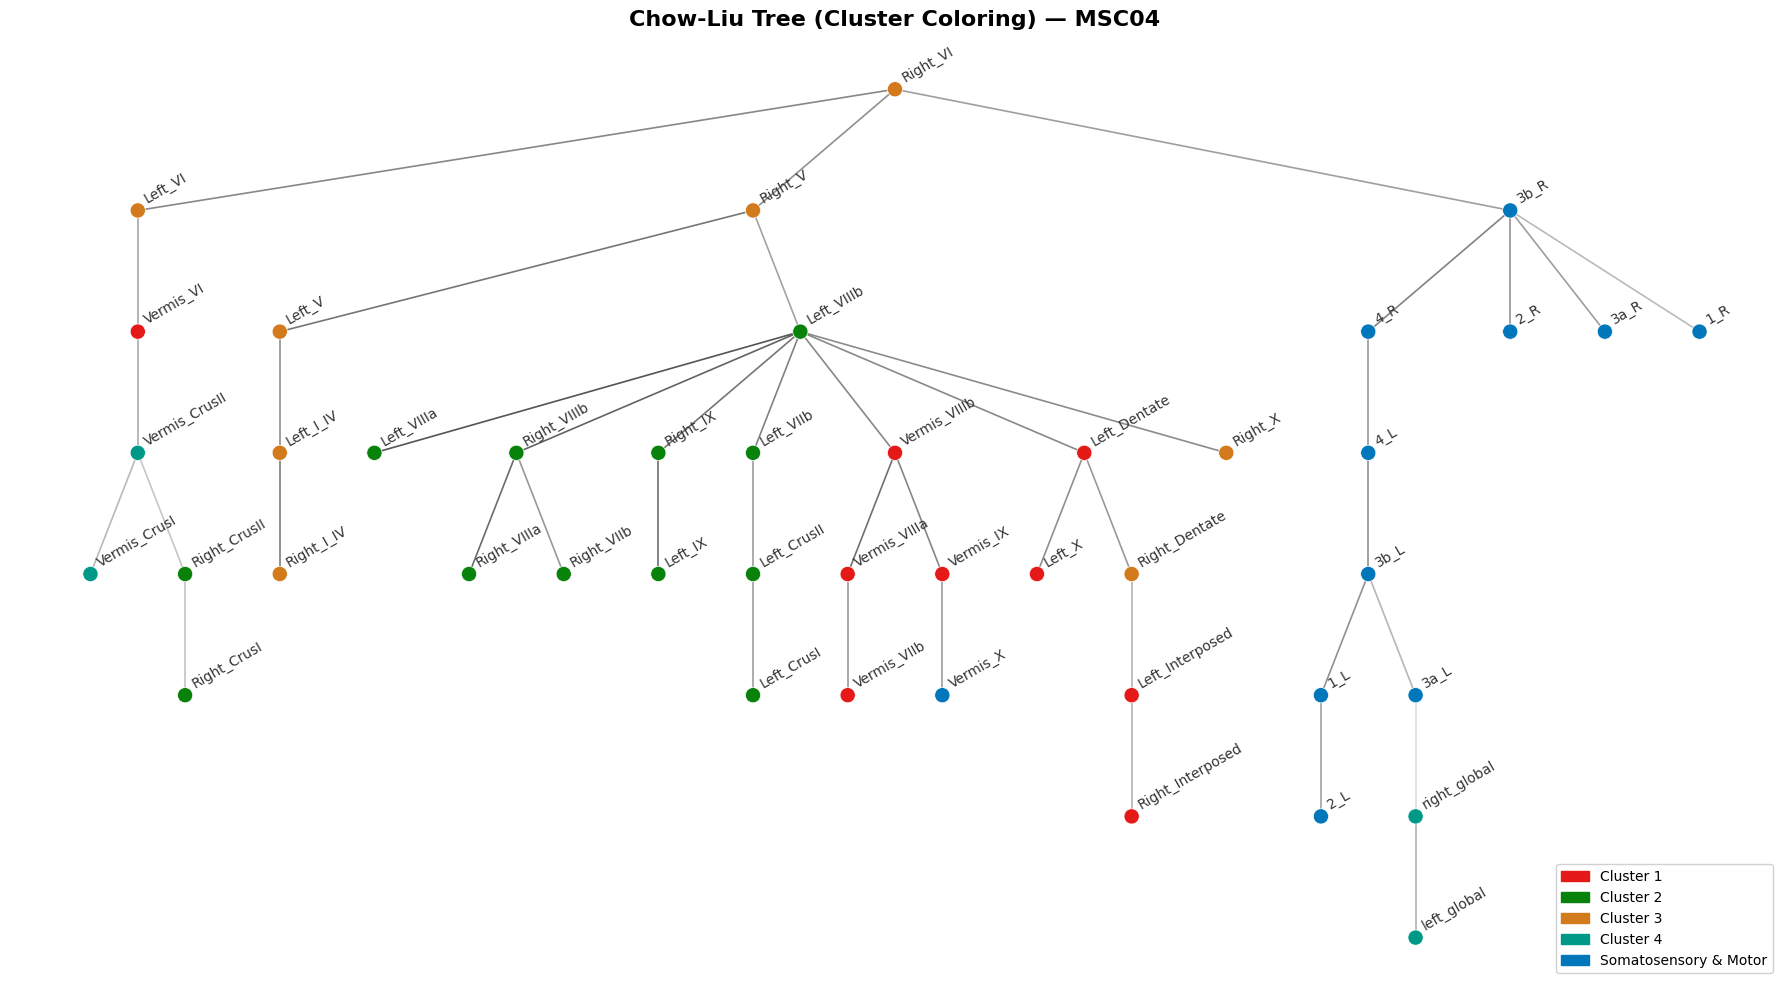

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_clusters_MSC07.pdf


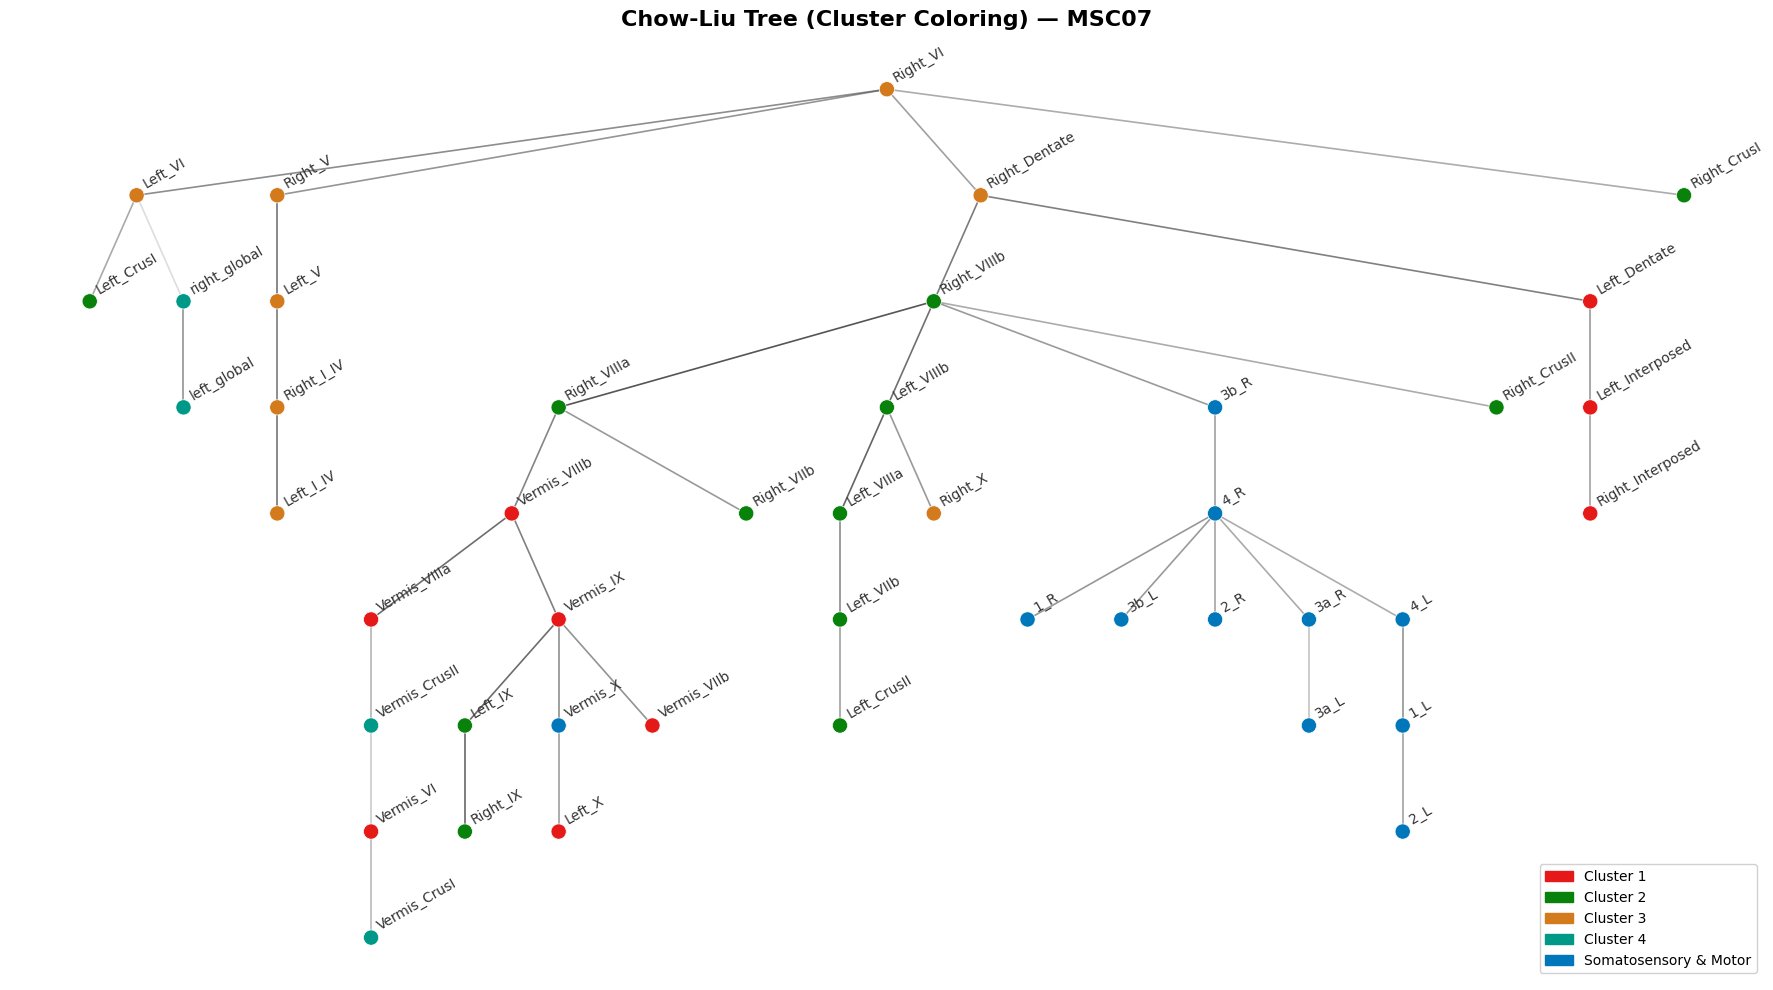

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/chow_liu_tree_clusters_MSC09.pdf


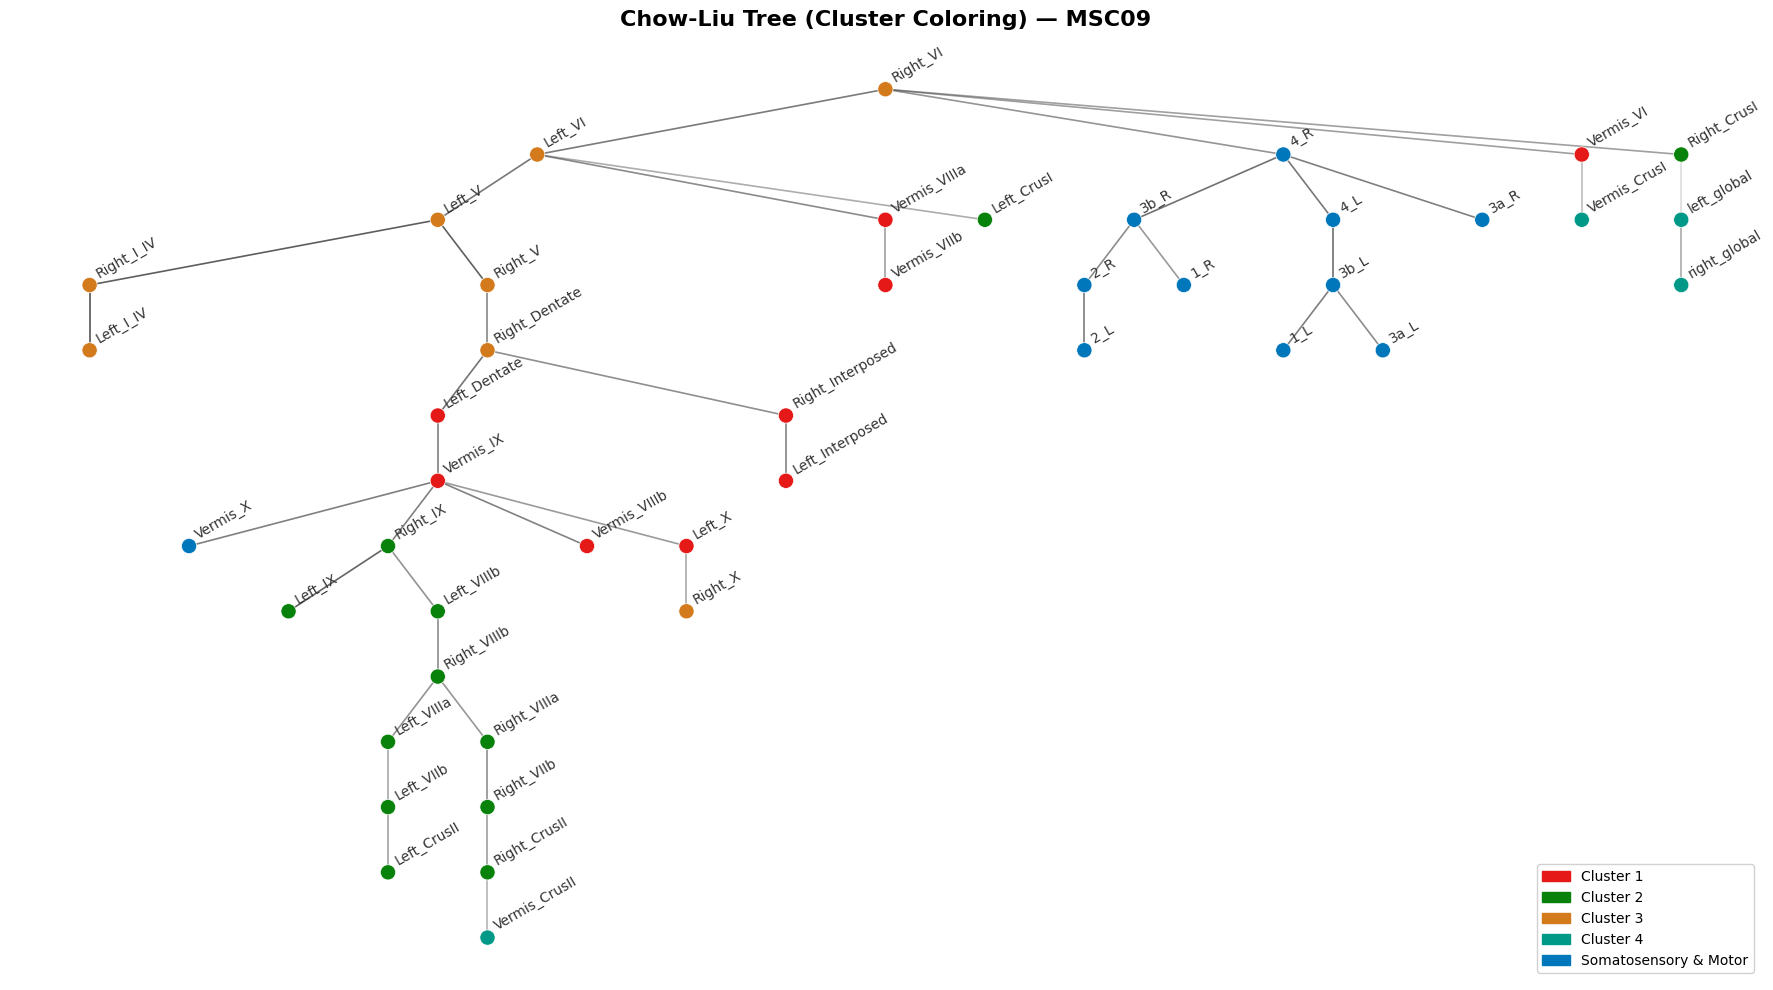

In [57]:
# Draw individual subject trees with cluster coloring
for s, name in zip(subjects, subject_display):
    save_path = os.path.join(output_dir, f'chow_liu_tree_clusters_{name}.pdf')
    draw_cluster_tree(
        selective_trees[s], name, all_labels, glasser_region_list,
        save_path=save_path
    )

## 5. Consensus Tree — Full Weighted

In [27]:
# Build consensus graph: union of all edges across subjects
consensus = nx.Graph()

# Add all nodes from selected set
for node in selected_nodes:
    consensus.add_node(node)

# Accumulate edges
edge_data = {}  # (u, v) -> list of weights
for s in subjects:
    for u, v, d in selective_trees[s].edges(data=True):
        key = (min(u, v), max(u, v))
        if key not in edge_data:
            edge_data[key] = []
        edge_data[key].append(d['weight'])

# Add edges with count and mean_weight
for (u, v), weights in edge_data.items():
    consensus.add_edge(u, v, count=len(weights), mean_weight=np.mean(weights))

print(f'Consensus graph: {consensus.number_of_nodes()} nodes, {consensus.number_of_edges()} edges')
for k in range(1, 5):
    n_edges = sum(1 for _, _, d in consensus.edges(data=True) if d['count'] >= k)
    print(f'  Edges in >= {k} subjects: {n_edges}')

Consensus graph: 44 nodes, 93 edges
  Edges in >= 1 subjects: 93
  Edges in >= 2 subjects: 49
  Edges in >= 3 subjects: 21
  Edges in >= 4 subjects: 9


In [32]:
def draw_consensus_tree(consensus, selected_networks, all_labels, glasser_region_list,
                        min_count=1, title=None, figsize=(20, 12), dpi=300,
                        save_path=None, highlight_unanimous=False):
    """
    Draw consensus tree with edge width/alpha encoding subject agreement.
    """
    # Filter edges by minimum count
    filtered = nx.Graph()
    for node in consensus.nodes:
        filtered.add_node(node)
    for u, v, d in consensus.edges(data=True):
        if d['count'] >= min_count:
            filtered.add_edge(u, v, **d)

    # Layout: use spanning tree of consensus for hierarchy
    # Find largest connected component for layout
    if filtered.number_of_edges() > 0:
        components = list(nx.connected_components(filtered))
        largest_cc = max(components, key=len)
        subgraph = filtered.subgraph(largest_cc).copy()

        # Use MST of subgraph for hierarchical layout
        layout_tree = nx.maximum_spanning_tree(subgraph, weight='mean_weight')
        root = max(layout_tree.nodes, key=lambda n: layout_tree.degree(n))
        directed = nx.bfs_tree(layout_tree, source=root)
        pos = hierarchy_pos(directed, root, width=2.0, vert_gap=0.6)

        # Place isolated nodes at bottom
        all_positioned = set(pos.keys())
        missing = [n for n in filtered.nodes if n not in all_positioned]
        if missing:
            y_min = min(p[1] for p in pos.values()) - 1.0
            for i, node in enumerate(missing):
                pos[node] = (i * 0.05, y_min)
    else:
        # No edges — spread nodes in a line
        pos = {n: (i * 0.05, 0) for i, n in enumerate(filtered.nodes)}
        root = list(filtered.nodes)[0] if filtered.nodes else 0

    # Node colors
    networks = get_node_regions(filtered, region_labels=glasser_region_list['cortex'])
    node_list = list(filtered.nodes)
    color_map = [NETWORK_COLORS.get(net, '#CCCCCC') for net in networks]

    # Draw
    fig, ax = plt.subplots(1, 1, figsize=figsize, facecolor='white')

    # Edge width and alpha by count
    count_to_width = {1: 0.5, 2: 1.2, 3: 2.2, 4: 3.5}
    count_to_alpha = {1: 0.25, 2: 0.45, 3: 0.7, 4: 1.0}

    for u, v, d in filtered.edges(data=True):
        cnt = d['count']
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        color = '#CC3311' if (highlight_unanimous and cnt == 4) else '#333333'
        ax.plot([x0, x1], [y0, y1], color=color,
                alpha=count_to_alpha.get(cnt, 1.0),
                linewidth=count_to_width.get(cnt, 1.0), zorder=1)

    # Nodes
    xs = [pos[n][0] for n in node_list]
    ys = [pos[n][1] for n in node_list]
    ax.scatter(xs, ys, c=color_map, s=120, zorder=2, edgecolors='white', linewidths=0.5)

    # Labels
    for node, (x, y) in zip(node_list, [(pos[n][0], pos[n][1]) for n in node_list]):
        label = all_labels[node] if node < len(all_labels) else str(node)
        ax.annotate(label, (x, y), fontsize=15, rotation=20,
                    ha='left', va='bottom', color='#333333',
                    xytext=(3, 3), textcoords='offset points')

    # Network legend
    net_patches = [mpatches.Patch(color=NETWORK_COLORS[net], label=net.replace('_', ' '))
                   for net in selected_networks]

    # Edge count legend
    from matplotlib.lines import Line2D
    edge_handles = []
    for cnt in sorted(count_to_width.keys()):
        if cnt >= min_count:
            edge_handles.append(Line2D([0], [0], color='#333333',
                                       linewidth=count_to_width[cnt],
                                       alpha=count_to_alpha[cnt],
                                       label=f'{cnt}/4 subjects'))

    all_handles = net_patches + edge_handles
    ax.legend(handles=all_handles, fontsize=9, loc='upper right',
              framealpha=0.9, edgecolor='#CCCCCC')

    if title is None:
        title = f'Consensus Chow-Liu Tree (N=4 subjects, edges in >= {min_count} subjects)'
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.axis('off')
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')

    plt.show()
    return fig

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/consensus_chow_liu_tree_full.pdf


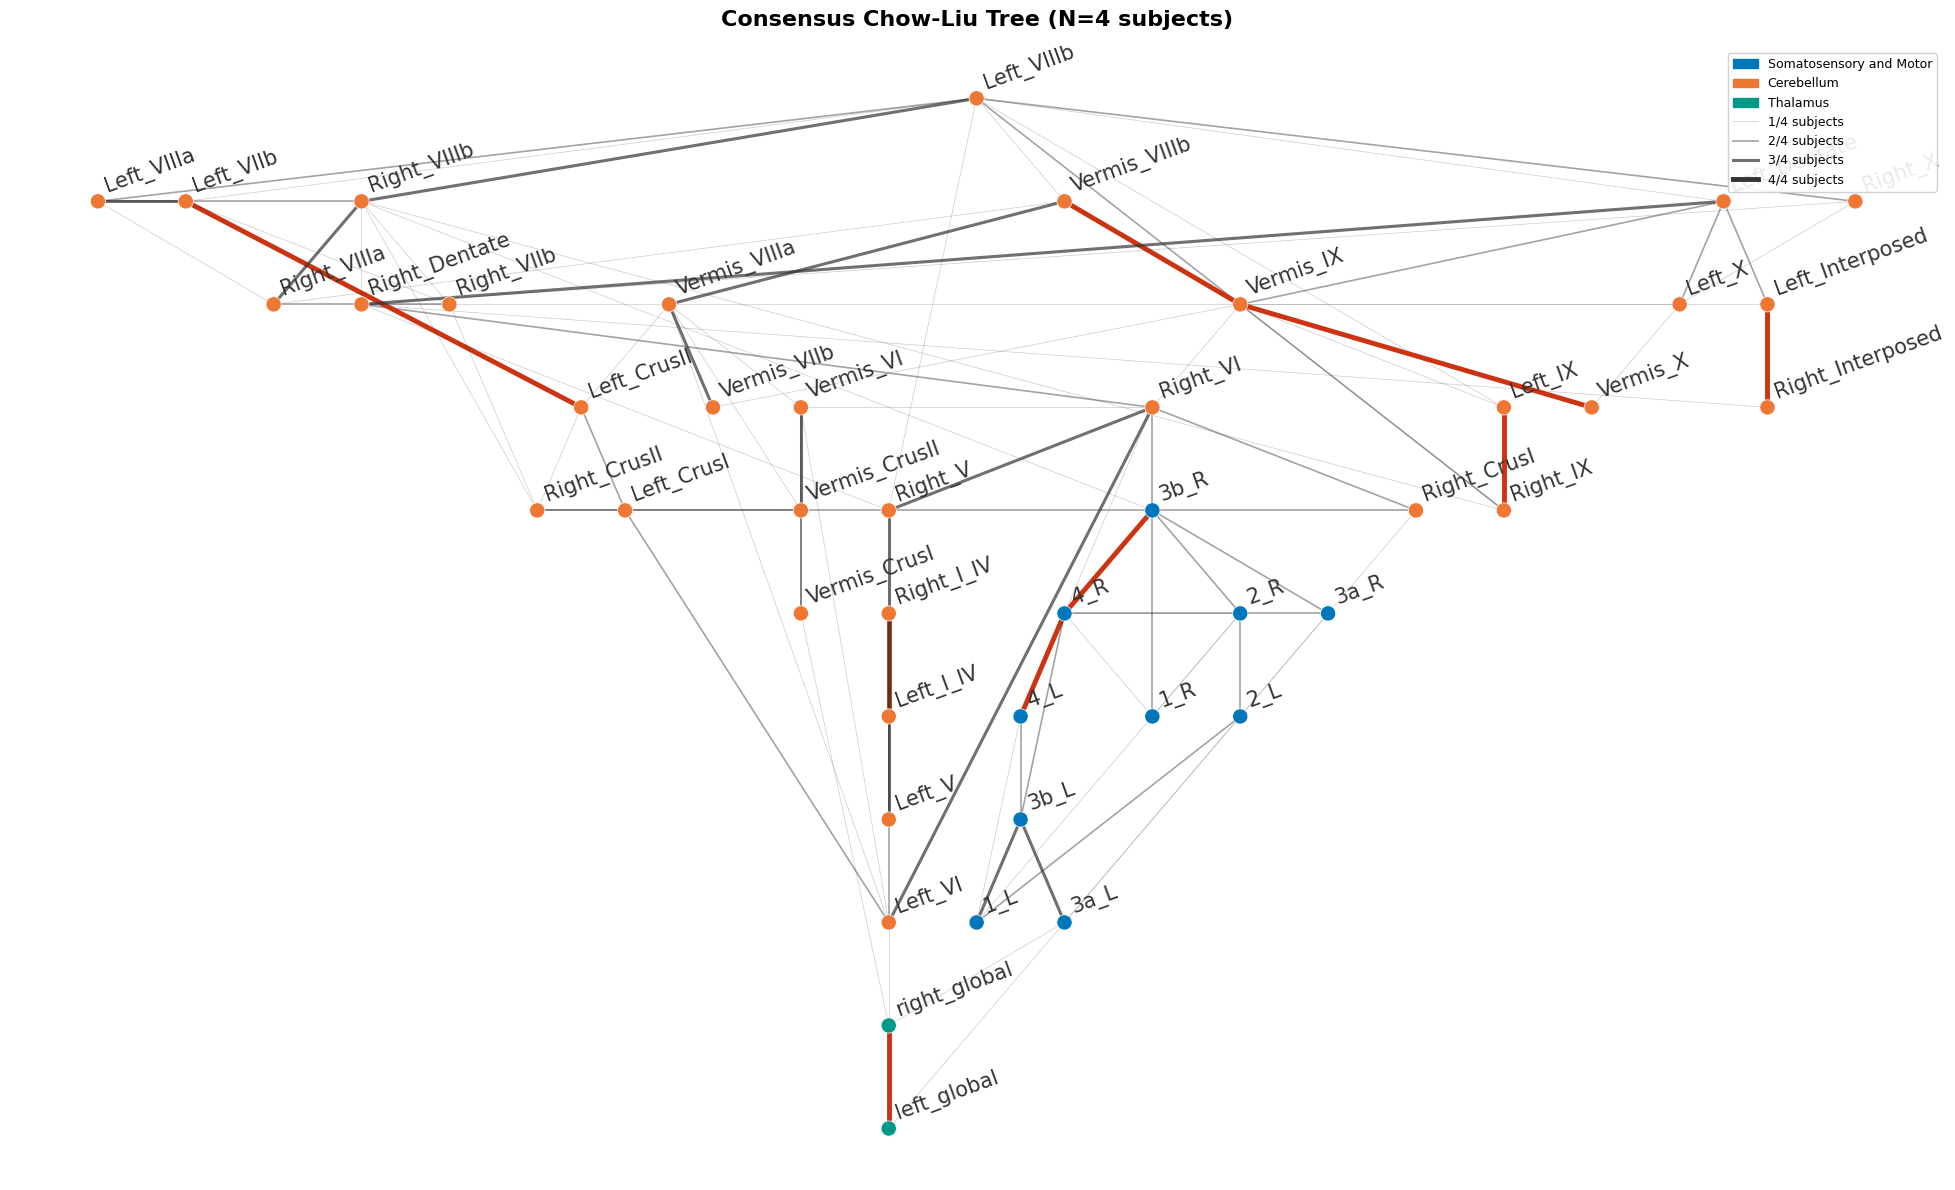

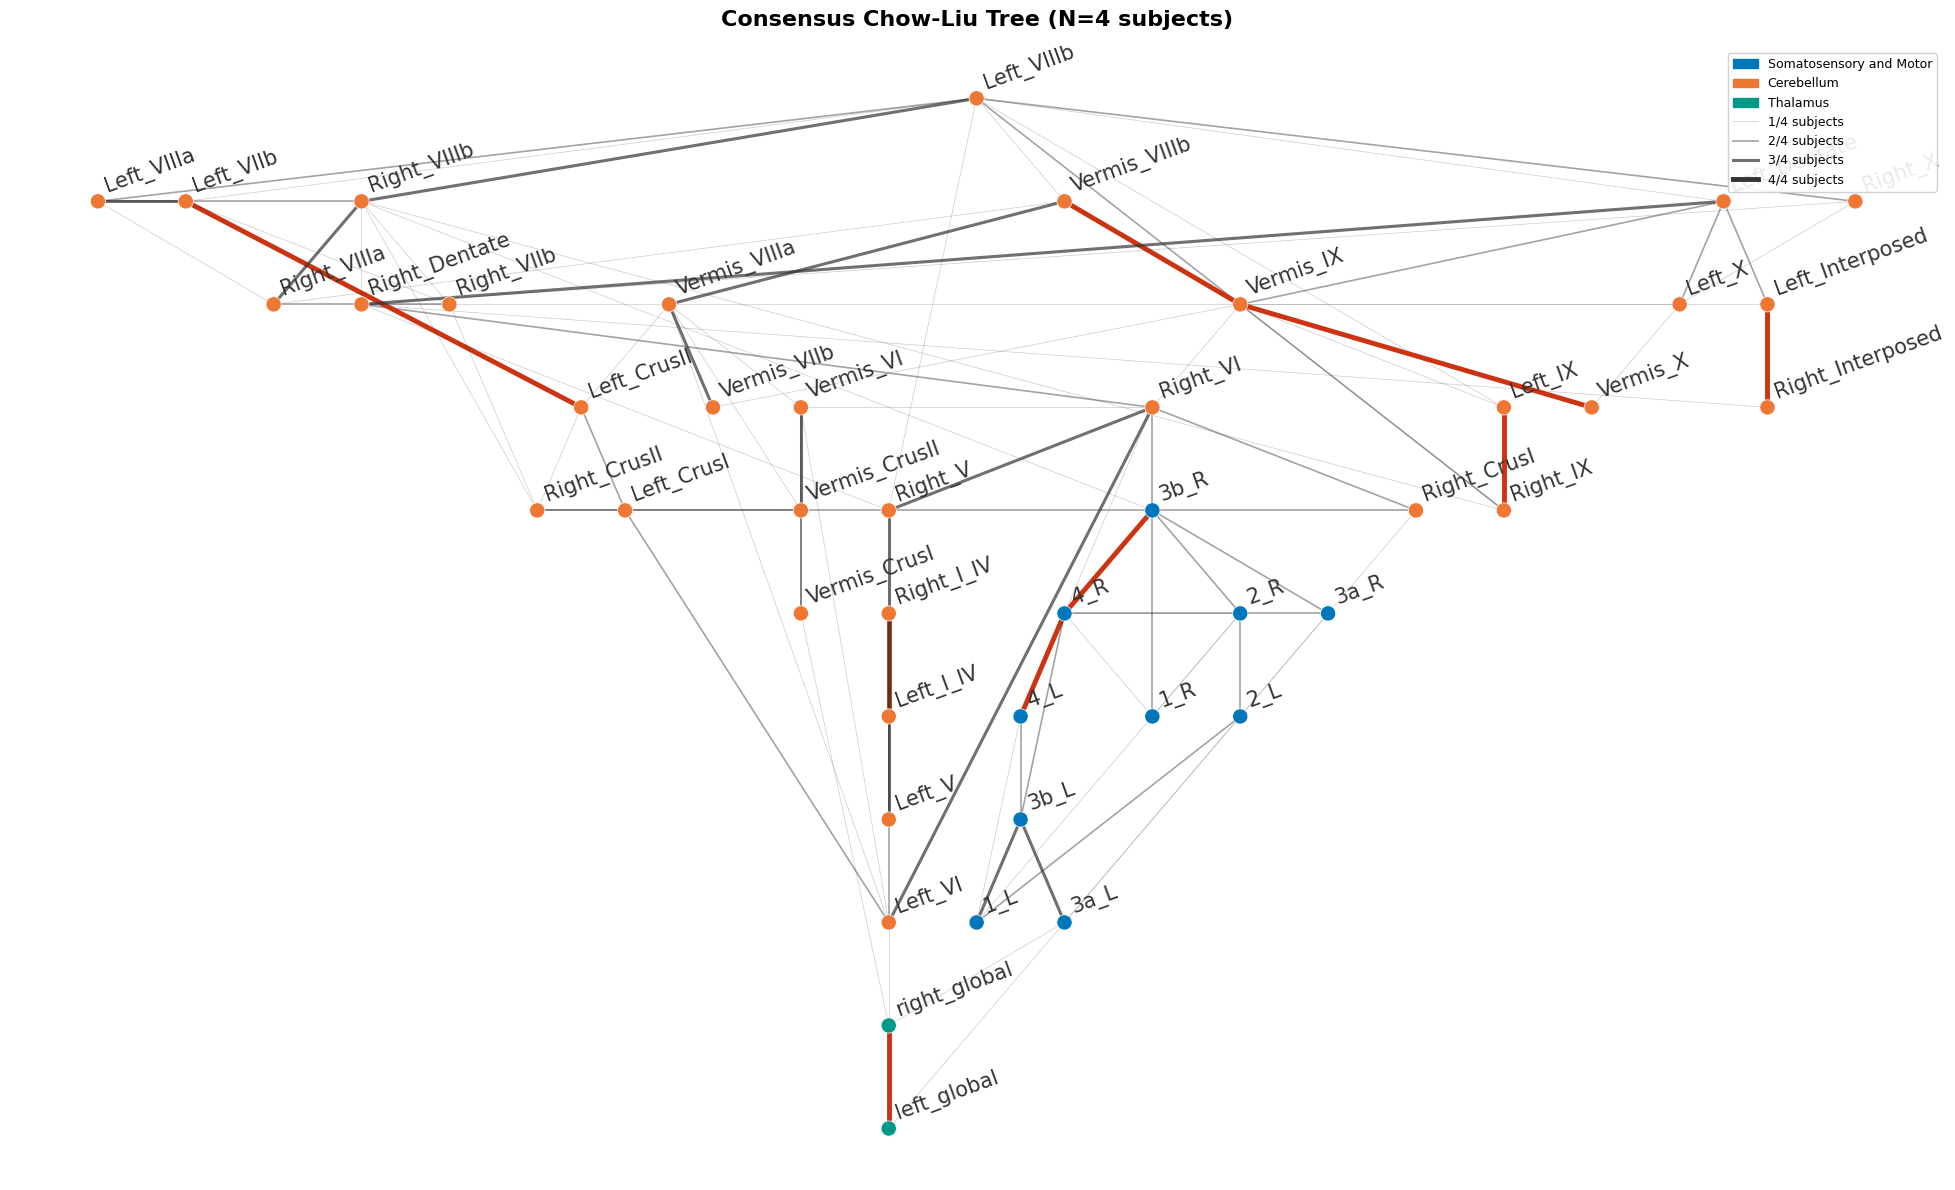

In [33]:
# Full consensus tree (all edges)
draw_consensus_tree(
    consensus, selected_networks, all_labels, glasser_region_list,
    min_count=1, highlight_unanimous=True,
    title='Consensus Chow-Liu Tree (N=4 subjects)',
    save_path=os.path.join(output_dir, 'consensus_chow_liu_tree_full.pdf')
)

## 6. Consensus Tree — Thresholded

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/consensus_chow_liu_tree_k3.pdf


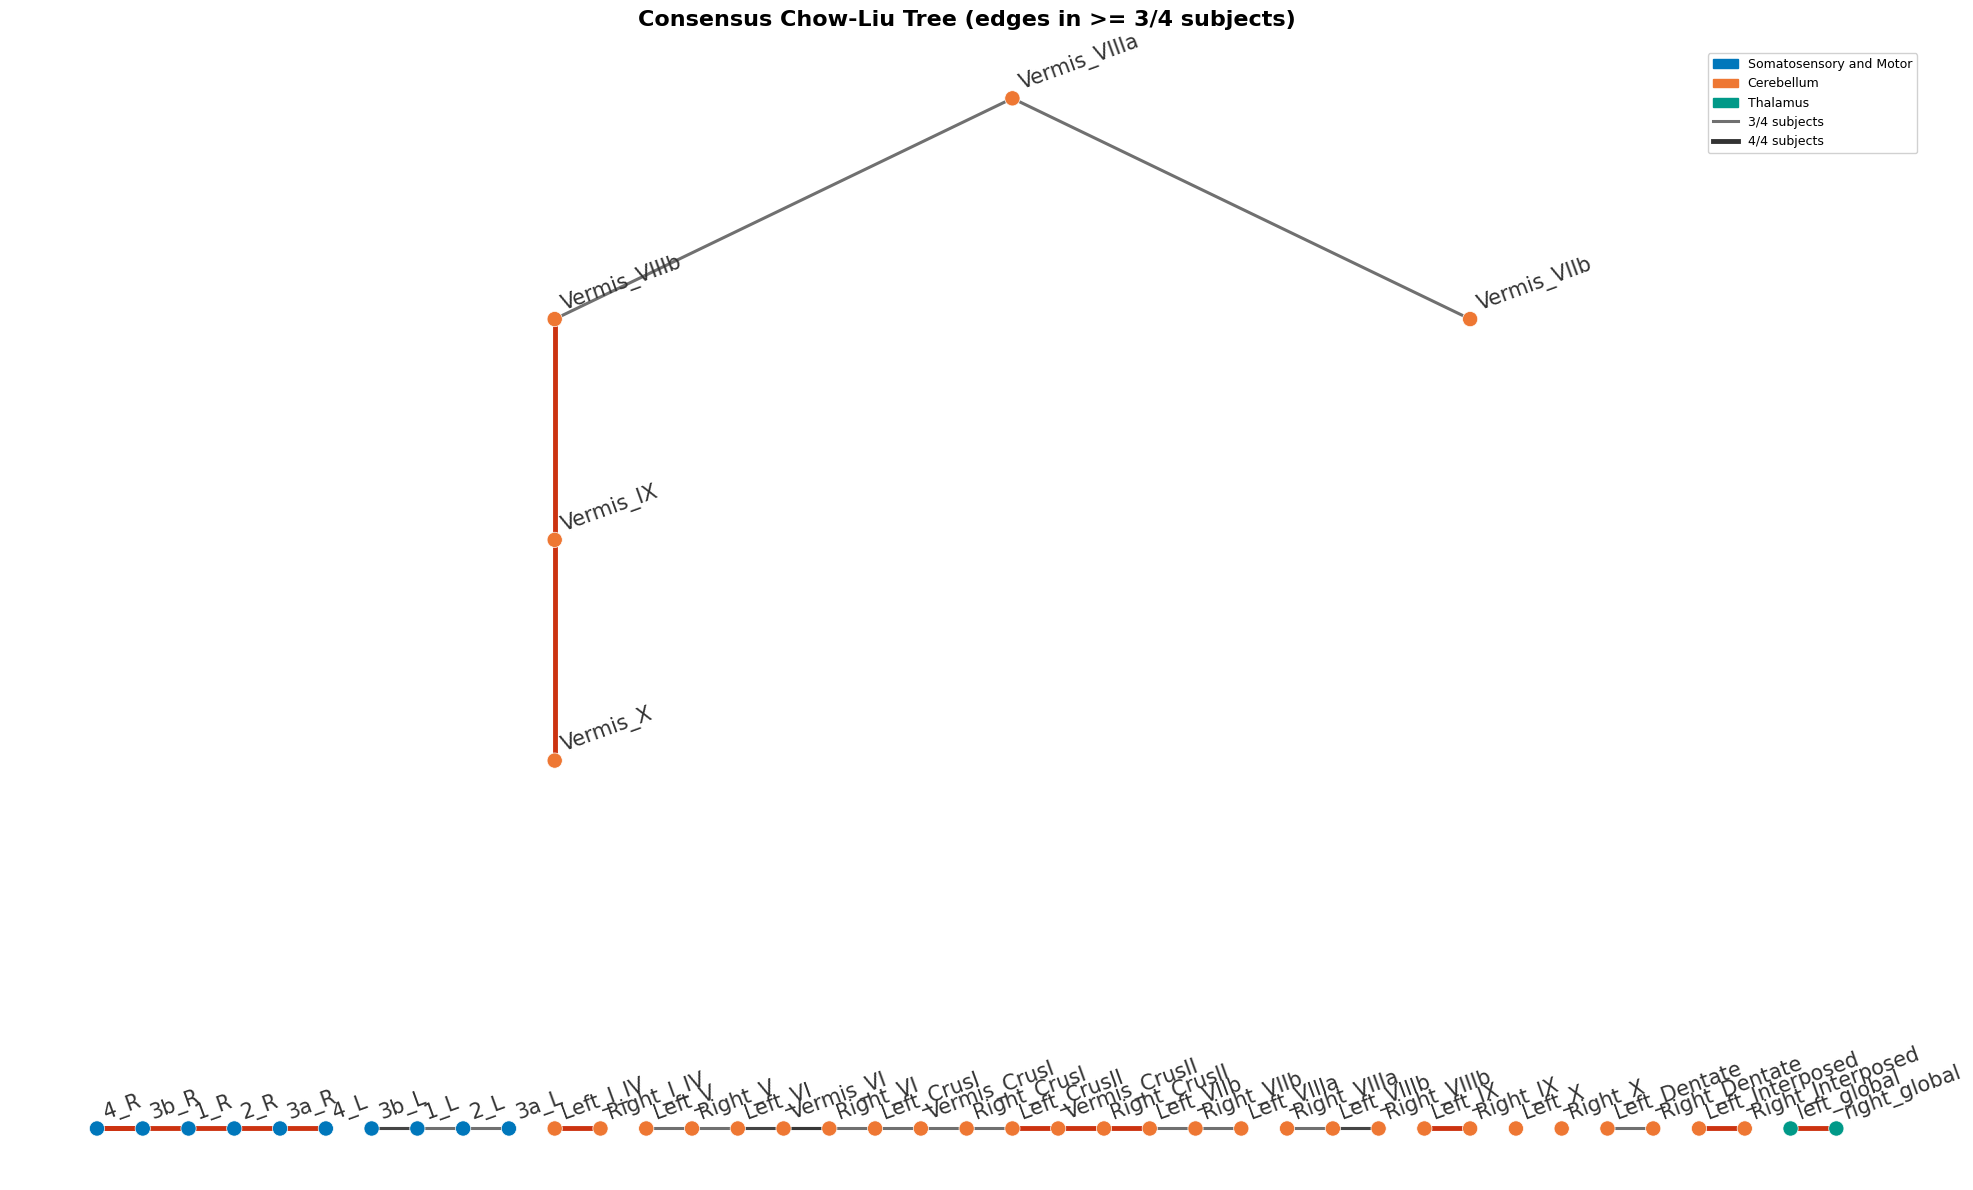

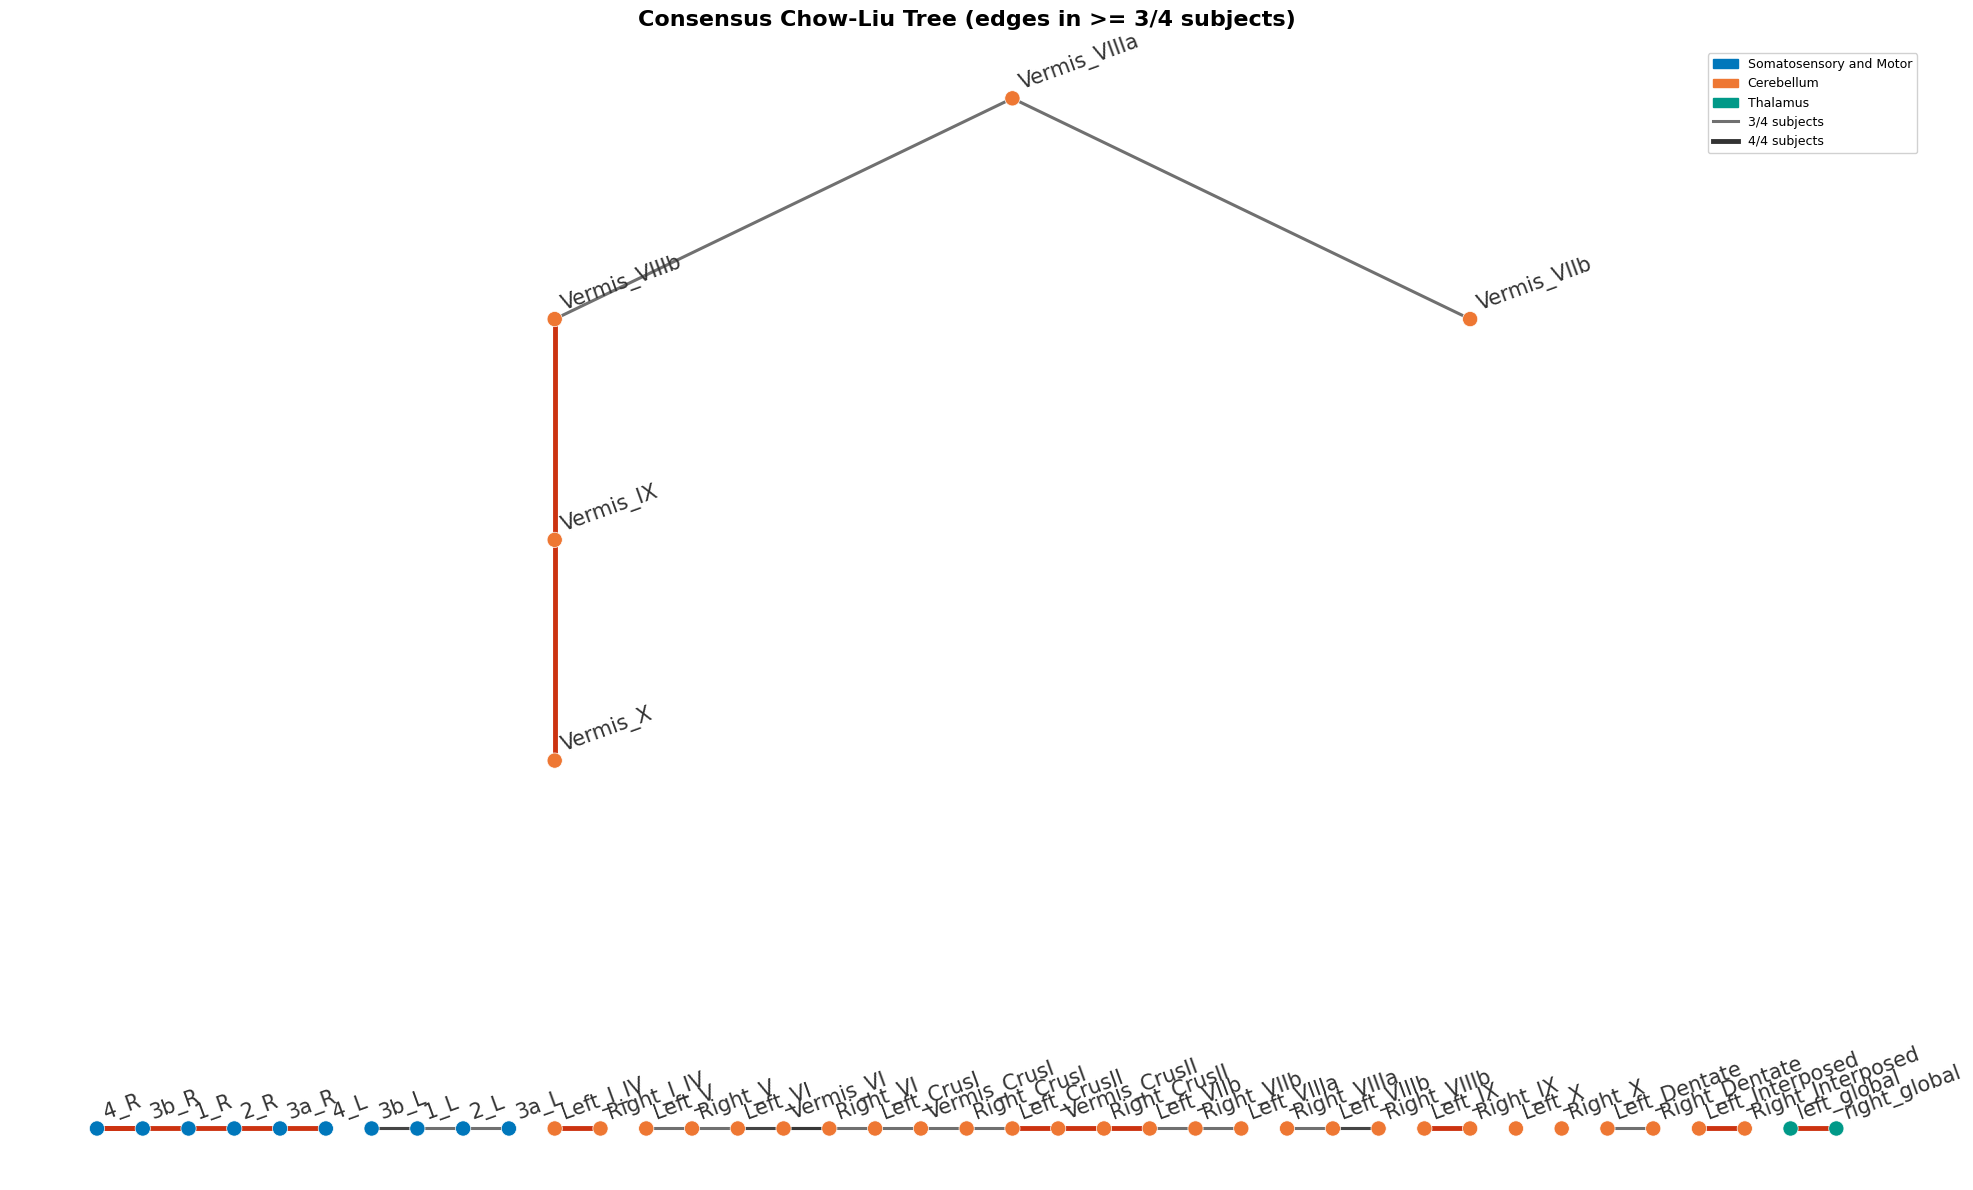

In [34]:
# Thresholded: edges in >= 3 subjects (75% agreement)
draw_consensus_tree(
    consensus, selected_networks, all_labels, glasser_region_list,
    min_count=3, highlight_unanimous=True,
    title='Consensus Chow-Liu Tree (edges in >= 3/4 subjects)',
    save_path=os.path.join(output_dir, 'consensus_chow_liu_tree_k3.pdf')
)

Saved: /Users/ajjain/Downloads/Code/fmri_connectivity_trees/code/jupyter_notebooks/midnight_scan_club/consensus_chow_liu_tree_k4.pdf


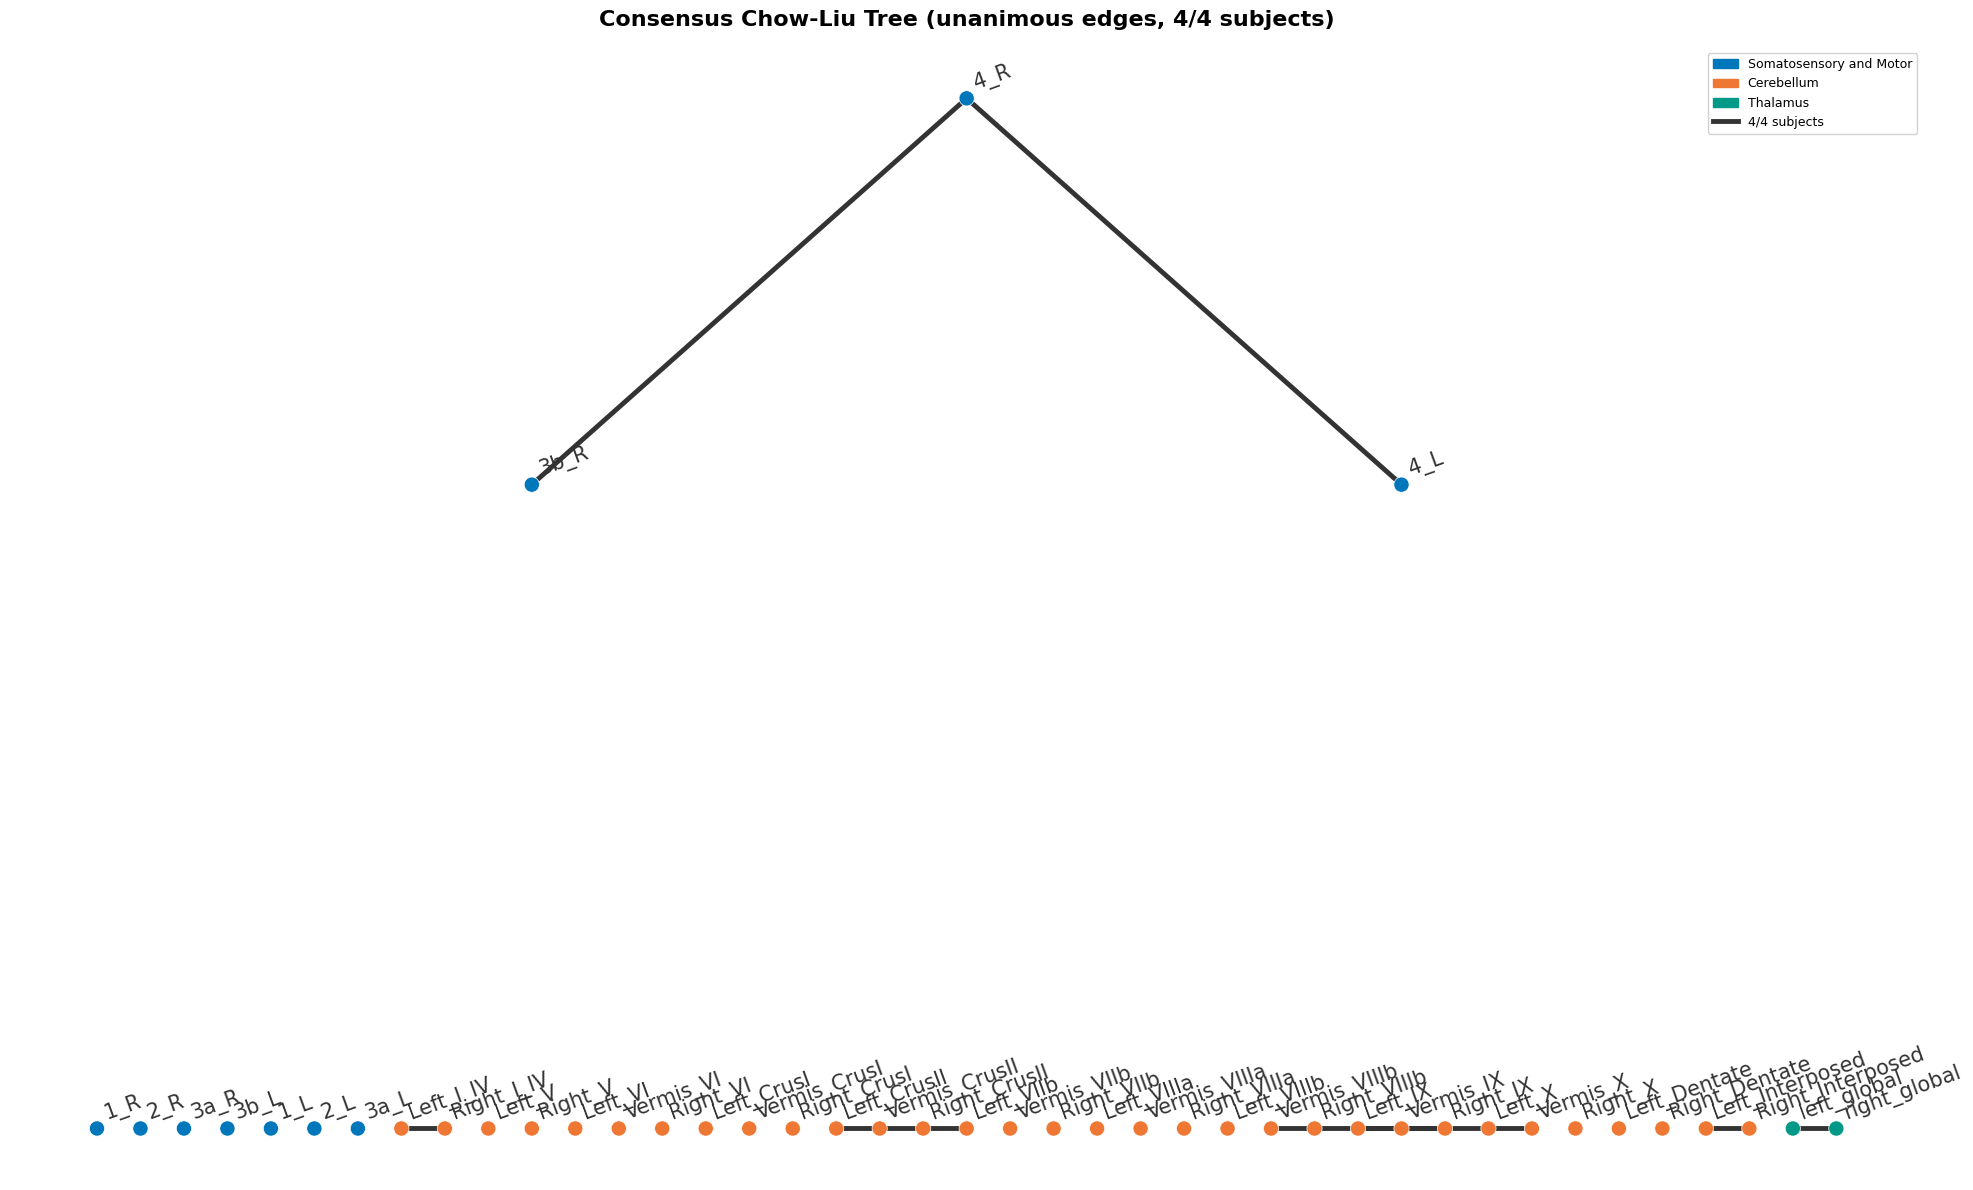

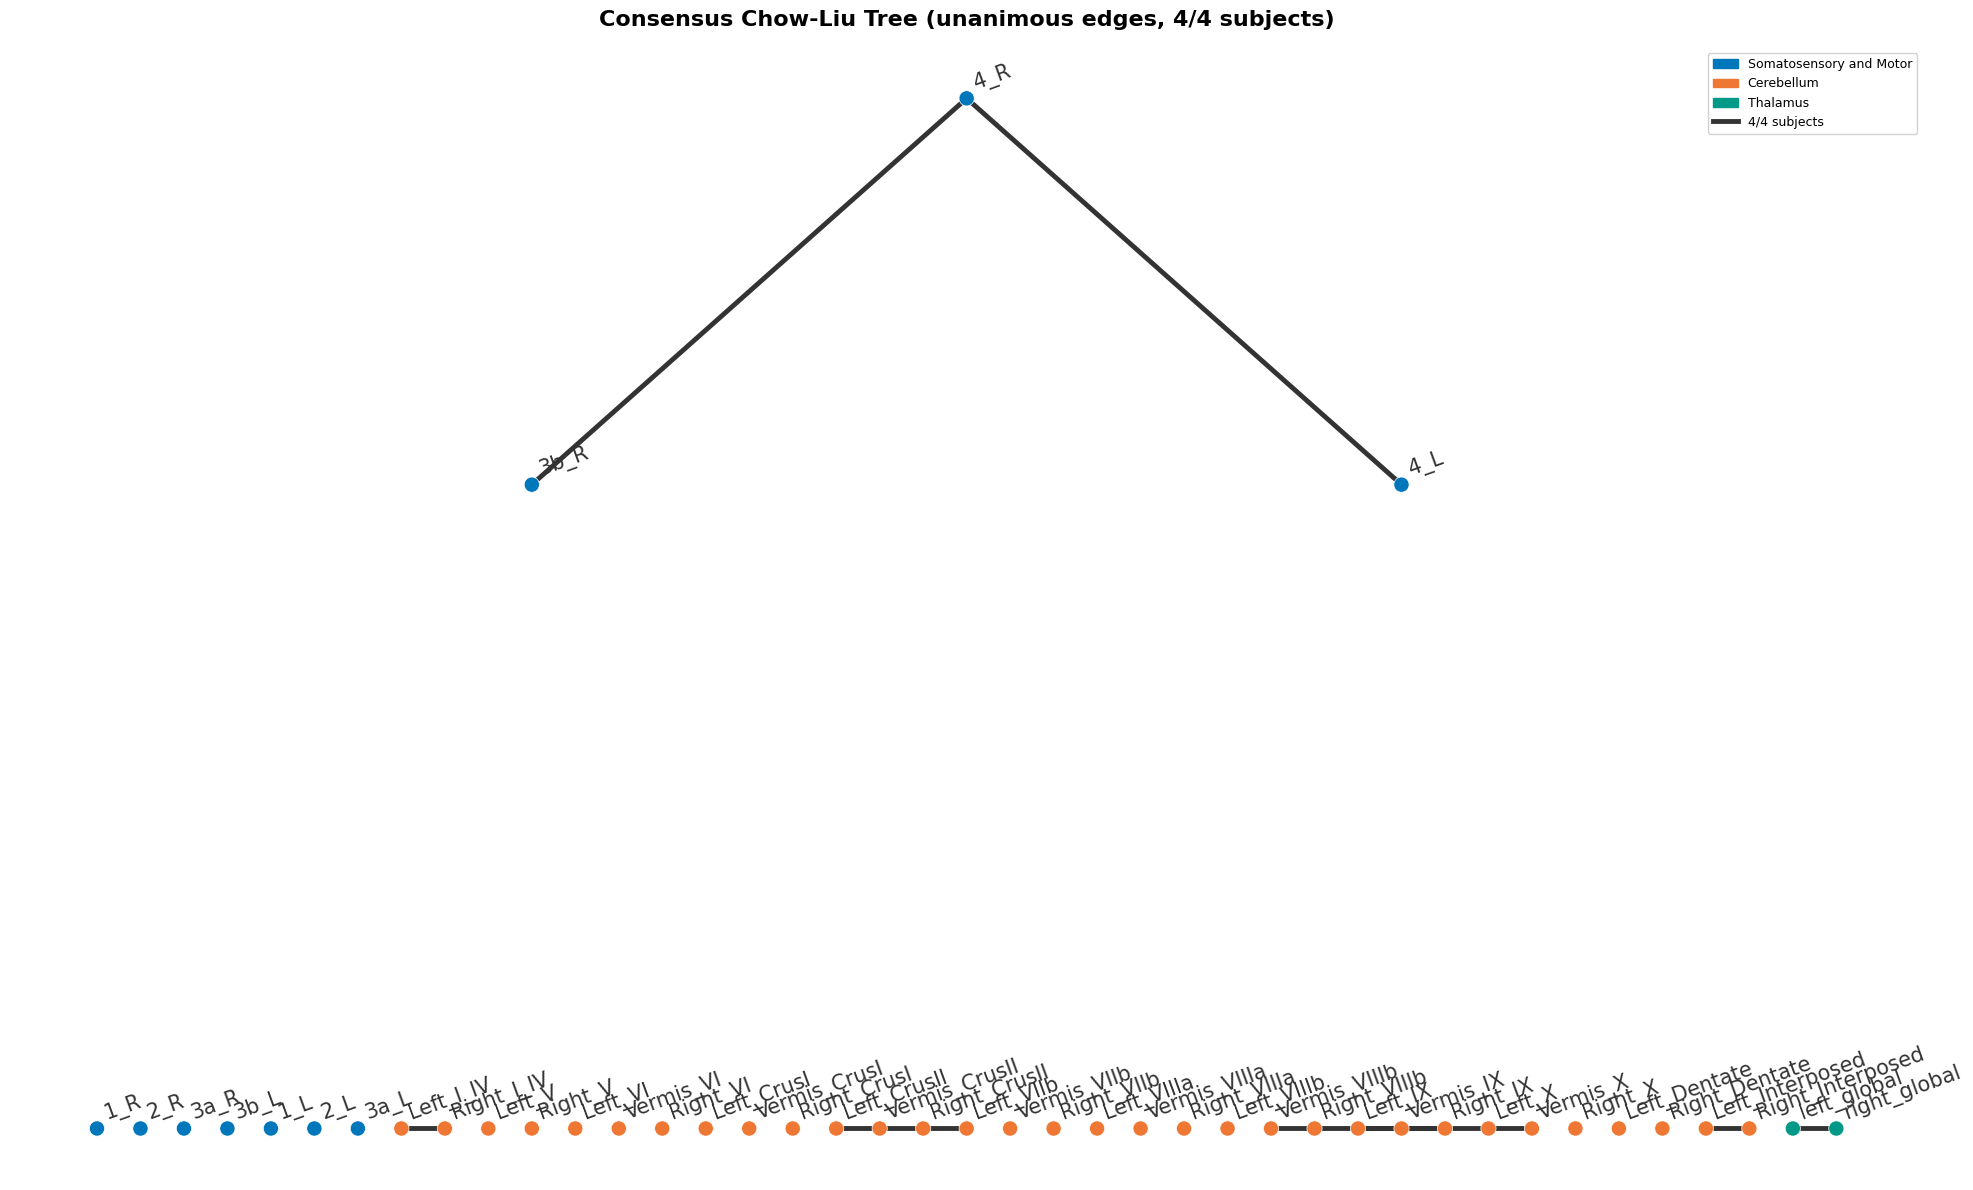

In [35]:
# Unanimous: edges in all 4 subjects
draw_consensus_tree(
    consensus, selected_networks, all_labels, glasser_region_list,
    min_count=4,
    title='Consensus Chow-Liu Tree (unanimous edges, 4/4 subjects)',
    save_path=os.path.join(output_dir, 'consensus_chow_liu_tree_k4.pdf')
)

## 7. Summary Statistics

In [36]:
# Per-subject edge counts
print('=== Per-Subject Edge Counts ===')
for s, name in zip(subjects, subject_display):
    print(f'  {name}: {selective_trees[s].number_of_edges()} edges')

# Consensus edges at each threshold
print('\n=== Consensus Edge Counts by Threshold ===')
for k in range(1, 5):
    n_edges = sum(1 for _, _, d in consensus.edges(data=True) if d['count'] >= k)
    print(f'  >= {k} subjects: {n_edges} edges')

=== Per-Subject Edge Counts ===
  MSC01: 43 edges
  MSC04: 43 edges
  MSC07: 43 edges
  MSC09: 43 edges

=== Consensus Edge Counts by Threshold ===
  >= 1 subjects: 93 edges
  >= 2 subjects: 49 edges
  >= 3 subjects: 21 edges
  >= 4 subjects: 9 edges


In [37]:
# Jaccard similarity between all pairs of subject trees
print('=== Pairwise Jaccard Similarity ===')

def tree_edge_set(tree):
    """Get canonical edge set (sorted tuples) from a tree."""
    return {(min(u, v), max(u, v)) for u, v in tree.edges()}

edge_sets = {s: tree_edge_set(selective_trees[s]) for s in subjects}

# Pairwise Jaccard
jaccard_matrix = np.zeros((len(subjects), len(subjects)))
for i, (s1, n1) in enumerate(zip(subjects, subject_display)):
    for j, (s2, n2) in enumerate(zip(subjects, subject_display)):
        if i == j:
            jaccard_matrix[i, j] = 1.0
        elif j > i:
            intersection = len(edge_sets[s1] & edge_sets[s2])
            union = len(edge_sets[s1] | edge_sets[s2])
            jacc = intersection / union if union > 0 else 0
            jaccard_matrix[i, j] = jacc
            jaccard_matrix[j, i] = jacc
            print(f'  {n1} vs {n2}: Jaccard = {jacc:.3f}  ({intersection} shared / {union} total edges)')

print(f'\n  Mean pairwise Jaccard: {jaccard_matrix[np.triu_indices(len(subjects), k=1)].mean():.3f}')

=== Pairwise Jaccard Similarity ===
  MSC01 vs MSC04: Jaccard = 0.344  (22 shared / 64 total edges)
  MSC01 vs MSC07: Jaccard = 0.229  (16 shared / 70 total edges)
  MSC01 vs MSC09: Jaccard = 0.246  (17 shared / 69 total edges)
  MSC04 vs MSC07: Jaccard = 0.303  (20 shared / 66 total edges)
  MSC04 vs MSC09: Jaccard = 0.344  (22 shared / 64 total edges)
  MSC07 vs MSC09: Jaccard = 0.323  (21 shared / 65 total edges)

  Mean pairwise Jaccard: 0.298


In [38]:
# Edge overlap count table
print('=== Edge Overlap Distribution ===')
count_dist = {1: 0, 2: 0, 3: 0, 4: 0}
for _, _, d in consensus.edges(data=True):
    count_dist[d['count']] += 1

for k in range(1, 5):
    print(f'  Edges in exactly {k} subject(s): {count_dist[k]}')
print(f'  Total unique edges: {sum(count_dist.values())}')

=== Edge Overlap Distribution ===
  Edges in exactly 1 subject(s): 44
  Edges in exactly 2 subject(s): 28
  Edges in exactly 3 subject(s): 12
  Edges in exactly 4 subject(s): 9
  Total unique edges: 93
